<a href="https://colab.research.google.com/github/w114050009-maker/MathAnalysisDataSci/blob/main/DataSciMath_HW2_HandWrittenClf(MNIST).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image, ImageOps, ImageEnhance
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [ ]:
from scipy.io import loadmat
import shutil

try:
    mnist = loadmat("dataset/mnist-original.mat")
except FileNotFoundError:
    print("File not found")
finally:
    pass


In [ ]:
# Function to add name and result into dataframe
df_table = pd.DataFrame()

def overall_pred_res(name, result, keep="last"):
    # Define row labels
    index = ["test accuracy", "my data 1", "my data 2"]

    # Build a column DataFrame with all three results
    new_col = pd.DataFrame(result,
                           columns=[name],
                           index=index)

    # Concatenate horizontally
    global df_table
    df_table = pd.concat([df_table, new_col], axis=1)

    if keep == "first":
        df_table = df_table.loc[:, ~df_table.columns.duplicated(keep="first")]
    elif keep == "last":
        df_table = df_table.loc[:, ~df_table.columns[::-1].duplicated(keep="first")[::-1]]
    elif keep == "none":
        df_table = df_table.loc[:, df_table.columns.drop_duplicates(keep=False)]

    return df_table

- Image.NEAREST：最快但品質差（像素化）
- Image.BILINEAR：線性插值，適合中等縮放
- Image.BICUBIC：立方插值，品質比 BILINEAR 好
- Image.LANCZOS：高品質濾波器，適合極端縮小

In [ ]:
# Convert png to test dataset
# in_test_dataset1 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son1"
in_test_dataset1 = "dataset/me"
in_test_dataset2 = "dataset/son22"
in_test_dataset3 = "dataset/son12"
out_test_dataset1 = "dataset/16x16/son1"
out_test_dataset2 = "dataset/28x28/son1"
out_test_dataset3 = "dataset/16x16/son2"
out_test_dataset4 = "dataset/28x28/son2"
out_test_dataset5 = "dataset/16x16/son3"
out_test_dataset6 = "dataset/28x28/son3"

in_plan = [in_test_dataset1, in_test_dataset2, in_test_dataset3]
out_plan = [out_test_dataset1, out_test_dataset2, out_test_dataset3, out_test_dataset4, out_test_dataset5, out_test_dataset6]
size_plan = [[16,16], [28,28]]

for i in range(3):
  for j in range(10):
    picture = f"{j}.png"
    format = Image.LANCZOS

    filename = os.path.join(in_plan[i], picture)
    img = Image.open(filename).convert("L")  # 轉為灰階

    img_resized = img.resize(size_plan[0],format)  # 調整大小16x16
    img_resized.save(os.path.join(out_plan[i*2], picture))  # 儲存處理後圖片

    img_resized = img.resize(size_plan[1], format)  # 調整大小28x28
    img_resized.save(os.path.join(out_plan[i*2+1], picture))  # 儲存處理後圖片
    print(f"Processed {filename}")

Processed dataset/me/0.png
Processed dataset/me/1.png
Processed dataset/me/2.png
Processed dataset/me/3.png
Processed dataset/me/4.png
Processed dataset/me/5.png
Processed dataset/me/6.png
Processed dataset/me/7.png
Processed dataset/me/8.png
Processed dataset/me/9.png
Processed dataset/son22/0.png
Processed dataset/son22/1.png
Processed dataset/son22/2.png
Processed dataset/son22/3.png
Processed dataset/son22/4.png
Processed dataset/son22/5.png
Processed dataset/son22/6.png
Processed dataset/son22/7.png
Processed dataset/son22/8.png
Processed dataset/son22/9.png
Processed dataset/son12/0.png
Processed dataset/son12/1.png
Processed dataset/son12/2.png
Processed dataset/son12/3.png
Processed dataset/son12/4.png
Processed dataset/son12/5.png
Processed dataset/son12/6.png
Processed dataset/son12/7.png
Processed dataset/son12/8.png
Processed dataset/son12/9.png


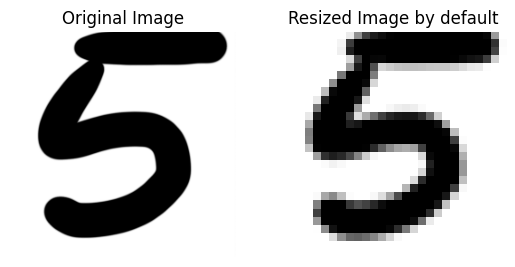

Original image size:  (250, 250)


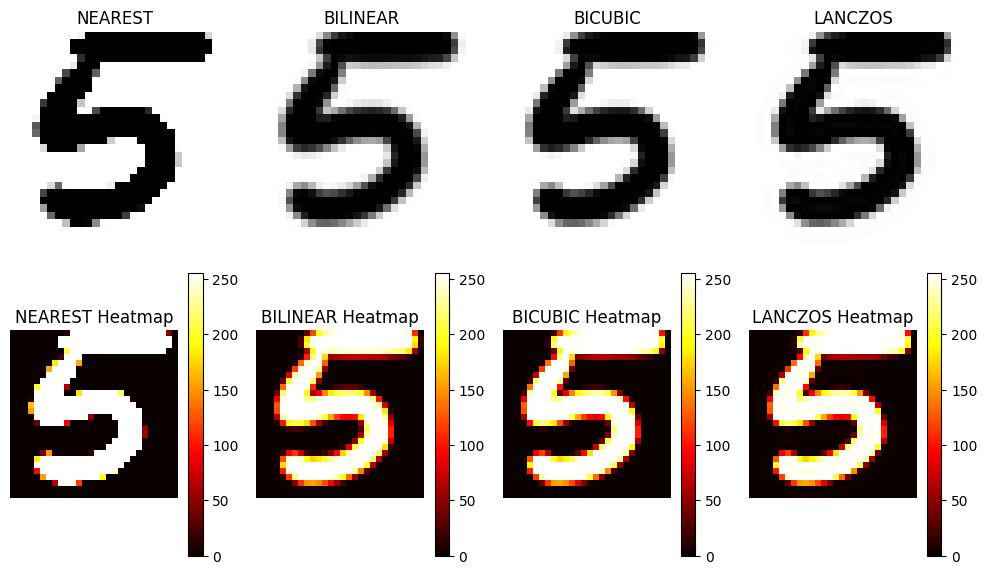

Resized image size:  (28, 28)


In [ ]:
# Compare 4 image formats
test_picture = "dataset/me/5.png"
img = Image.open(test_picture).convert("L")

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="binary")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(img.resize((28,28)), cmap="binary")
plt.axis("off")
plt.title("Resized Image by default")
plt.show()

print("Original image size: ", img.size)

methods = {
    "NEAREST": Image.NEAREST,
    "BILINEAR": Image.BILINEAR,
    "BICUBIC": Image.BICUBIC,
    "LANCZOS": Image.LANCZOS
}

# 縮小到 16x16 並顯示原圖 + heatmap
plt.figure(figsize=(10, 6))

for i, (name, method) in enumerate(methods.items(), 1):
    resized = img.resize((28, 28), method)
    arr = np.array(resized)

    # 左邊顯示影像
    plt.subplot(2, 4, i)
    plt.imshow(resized, cmap="binary")
    plt.title(name)
    plt.axis("off")

    # 右邊顯示 heatmap
    plt.subplot(2, 4, i+4)
    plt.imshow(arr, cmap="hot")
    plt.colorbar()
    plt.title(f"{name} Heatmap")
    plt.axis("off")

plt.tight_layout()
plt.show()
print("Resized image size: ", resized.size)

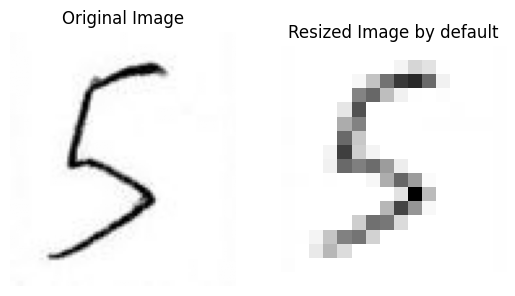

Original image size:  (87, 98)


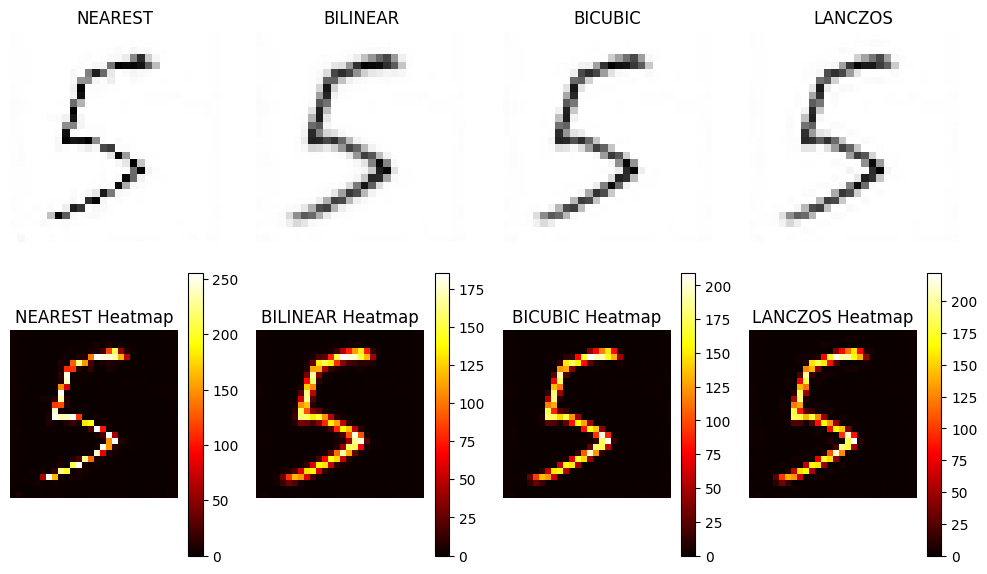

Resized image size:  (28, 28)


In [ ]:
# Compare 4 image formats
test_picture = "dataset/son12/5.png"
img = Image.open(test_picture).convert("L")

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="binary")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(img.resize((16,16)), cmap="binary")
plt.axis("off")
plt.title("Resized Image by default")
plt.show()

print("Original image size: ", img.size)

methods = {
    "NEAREST": Image.NEAREST,
    "BILINEAR": Image.BILINEAR,
    "BICUBIC": Image.BICUBIC,
    "LANCZOS": Image.LANCZOS
}

# 縮小到 16x16 並顯示原圖 + heatmap
plt.figure(figsize=(10, 6))

for i, (name, method) in enumerate(methods.items(), 1):
    resized = img.resize((28, 28), method)
    arr = np.array(resized)

    # 左邊顯示影像
    plt.subplot(2, 4, i)
    plt.imshow(resized, cmap="binary")
    plt.title(name)
    plt.axis("off")

    # 右邊顯示 heatmap
    plt.subplot(2, 4, i+4)
    plt.imshow(arr, cmap="hot")
    plt.colorbar()
    plt.title(f"{name} Heatmap")
    plt.axis("off")

plt.tight_layout()
plt.show()
print("Resized image size: ", resized.size)

Original image size:  (250, 250)


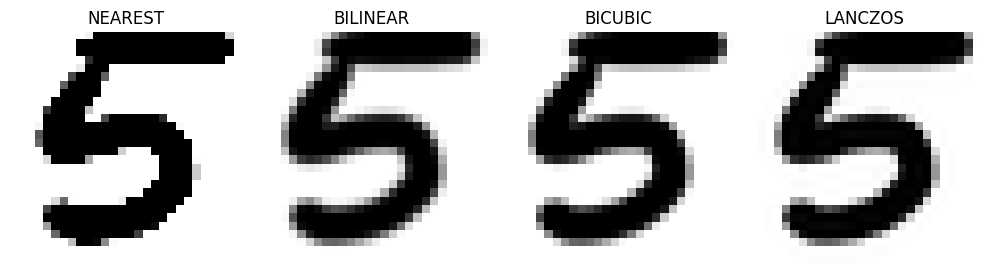

In [ ]:
# @title
# Compare 4 image formats
test_picture = "dataset/me/5.png"
img = Image.open(test_picture).convert("L")

print("Original image size: ", img.size)
methods = {
    "NEAREST": Image.NEAREST,
    "BILINEAR": Image.BILINEAR,
    "BICUBIC": Image.BICUBIC,
    "LANCZOS": Image.LANCZOS
}

# 縮小到 16x16 並顯示
plt.figure(figsize=(10, 3))
for i, (name, method) in enumerate(methods.items(), 1):
    resized = img.resize((28, 28), method)
    plt.subplot(1, 4, i)
    plt.imshow(resized, cmap="binary")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
np.array(resized)/255

array([[0.00784314, 0.00392157, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00392157,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00392157, 0.00392157],
       [0.00784314, 0.00392157, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00784314,
        0.00784314, 0.01568627, 0.01568627, 0.00784314, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00392157, 0.00392157],
       [0.00392157, 0.00392157, 0.00392157, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00392157, 0.00392157, 0.01960784, 0.01176471, 0.        ,
        0.        , 0.    

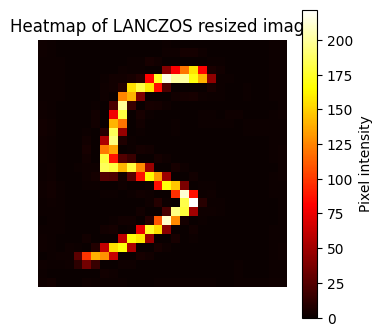

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Example: pick one method from your dictionary
name, method = list(methods.items())[3]   # just take the first method
resized = img.resize((28, 28), method)

# Convert to NumPy array
arr = np.array(resized)

# Plot as heatmap
plt.figure(figsize=(4,4))
plt.imshow(arr, cmap="hot")   # try "viridis", "hot", "plasma", etc. for different looks
plt.colorbar(label="Pixel intensity")
plt.title(f"Heatmap of {name} resized image")
plt.axis("off")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

def getMnistDataSet():
    # mnist_data: (784, N) → 轉成 (N, 784)
    X = mnist["data"].T
    y = mnist["label"][0]

    x = X/255

    # 先切 Train / Test
    x_Train, x_Test, y_Train, y_Test = train_test_split(
        x, y, test_size=0.2, random_state=42, stratify=y
    )

    return x_Train, y_Train, x_Test, y_Test

In [ ]:
def plot_image(image):
  fig = plt.gcf()
  fig.set_size_inches(2, 2)
  plt.imshow(image, cmap='binary')
  plt.show()

In [ ]:
def plot_images_labels_prediction(images,labels, prediction,idx,num=10):
  fig = plt.gcf()
  fig.set_size_inches(12, 14)
  if num>25: num=25
  for i in range(0, num):
    ax=plt.subplot(5,5, 1+i)
    ax.imshow(images.iloc[idx, np.arange(0, 784)].values.reshape([28, 28]), cmap='binary')
    title= "label=" +str(labels.iloc[idx,0])
    if len(prediction)>0:
      title+=",predict="+str(prediction.iloc[idx,0])

    ax.set_title(title,fontsize=10)
    ax.set_xticks([]);ax.set_yticks([])
    idx+=1
  plt.show()

## NumPy 的  在 2D 陣列上的行為：
*   對於 1D 向量， 是標準的歐式距離
*   對於 2D 矩陣， 是 矩陣的最大奇異值（spectral norm），不是元素平方和的平方根。

In [ ]:
# 2-norm
def norm2 (a, ak):
  # return np.linalg.norm(a-ak, ord='fro')
  return np.linalg.norm(a-ak, 2)

In [ ]:
# Get Train and Test dataset
x_Train, y_Train, x_Test, y_Test = getMnistDataSet()
print("training set (28x28) : %d piece(s)" % x_Train.shape[0])
print("testing set (28x28) : %d piece(s)" % x_Test.shape[0])

training set (28x28) : 56000 piece(s)
testing set (28x28) : 14000 piece(s)


In [ ]:
x_Train_data = pd.concat([pd.DataFrame(x_Train),pd.DataFrame(y_Train, columns=['digital'])], axis=1)
x_Test_data = pd.concat([pd.DataFrame(x_Test),pd.DataFrame(y_Test, columns=['digital'])], axis=1)

In [ ]:
# Show data value
x_Train_data.iloc[0, np.arange(0, 784)].values.reshape([28, 28])

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

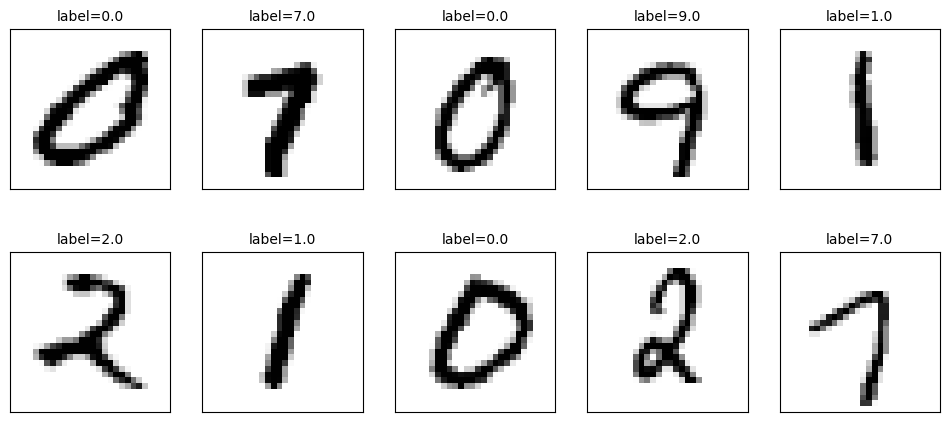

In [ ]:
# Train dataset
plot_images_labels_prediction(x_Train_data.loc[:,np.arange(0, 784)], x_Train_data.loc[:,['digital']],[],0,)

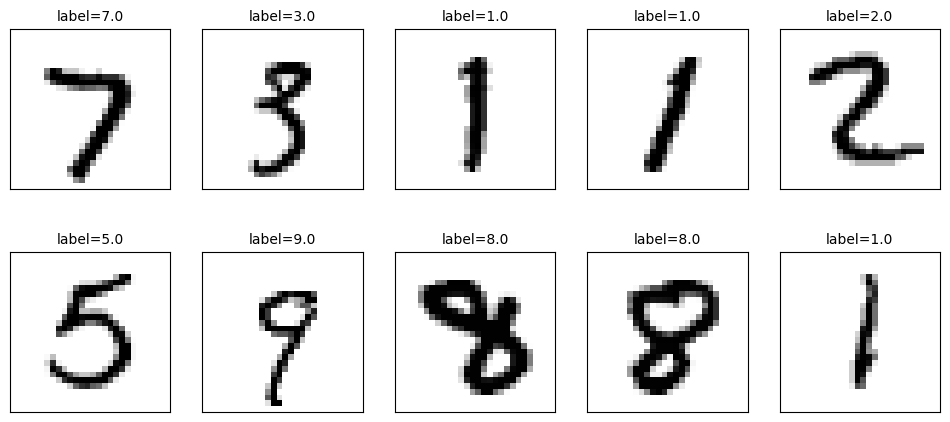

In [ ]:
# Test dataset
plot_images_labels_prediction(x_Test_data.loc[:,np.arange(0, 784)], x_Test_data.loc[:,['digital']],[],0,)

In [ ]:
feature_names = [str(i) for i in range(10)] + ['Total']

# 統計每個數字類別的樣本數（0–9），缺的補 0
train_counts = x_Train_data['digital'].value_counts().reindex(range(10), fill_value=0).to_numpy()
test_counts = x_Test_data['digital'].value_counts().reindex(range(10), fill_value=0).to_numpy()

# 加上總數
train_row = np.append(train_counts, x_Train_data.shape[0])
test_row = np.append(test_counts, x_Test_data.shape[0])

# 組成 DataFrame
df = pd.DataFrame([train_row, test_row], columns=feature_names, index=["Train", "Test"])
df

,0,1,2,3,4,5,6,7,8,9,Total
Train,5522,6302,5592,5713,5459,5050,5501,5834,5460,5567,56000
Test,1381,1575,1398,1428,1365,1263,1375,1459,1365,1391,14000


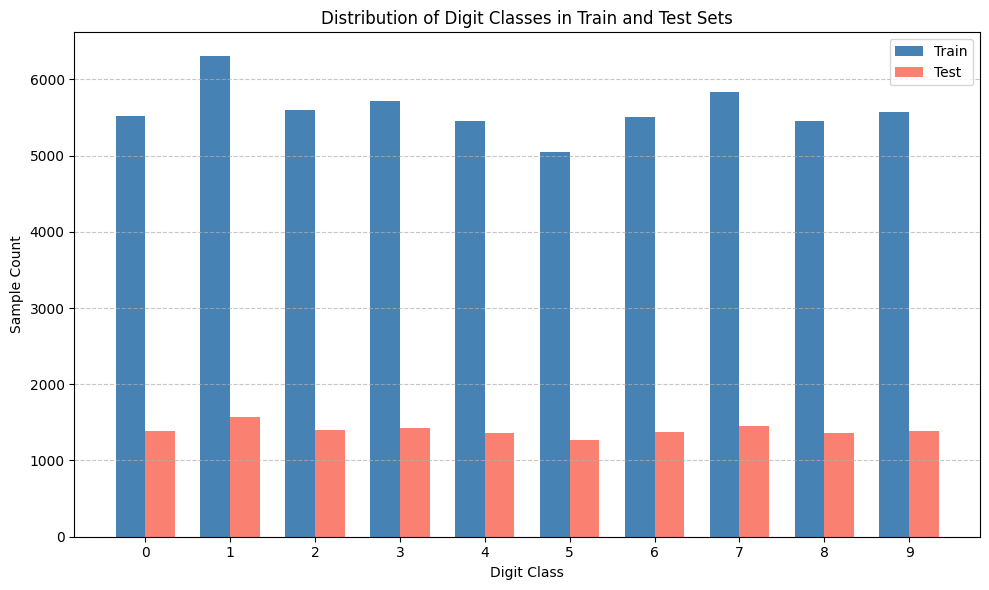

In [ ]:
x = np.arange(len(feature_names) - 1)  # 0–9
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df.loc["Train"][:-1], width, label='Train', color='steelblue')
plt.bar(x + width/2, df.loc["Test"][:-1], width, label='Test', color='salmon')

plt.xticks(x, feature_names[:-1])
plt.xlabel('Digit Class')
plt.ylabel('Sample Count')
plt.title('Distribution of Digit Classes in Train and Test Sets')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


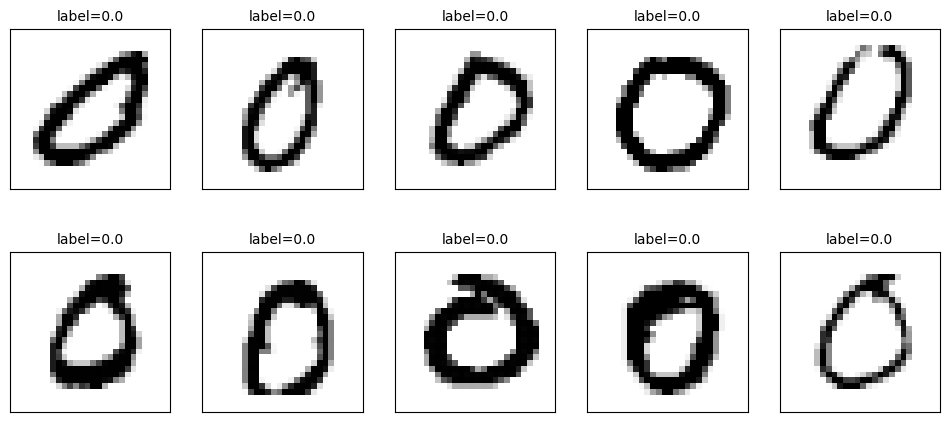

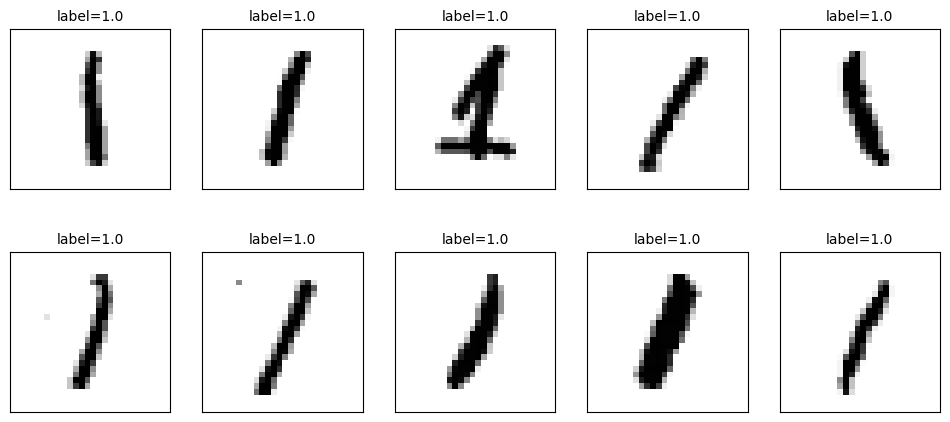

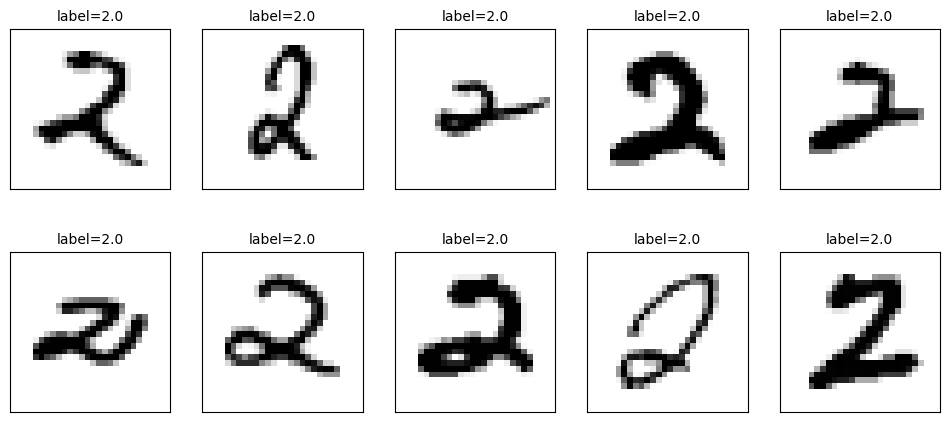

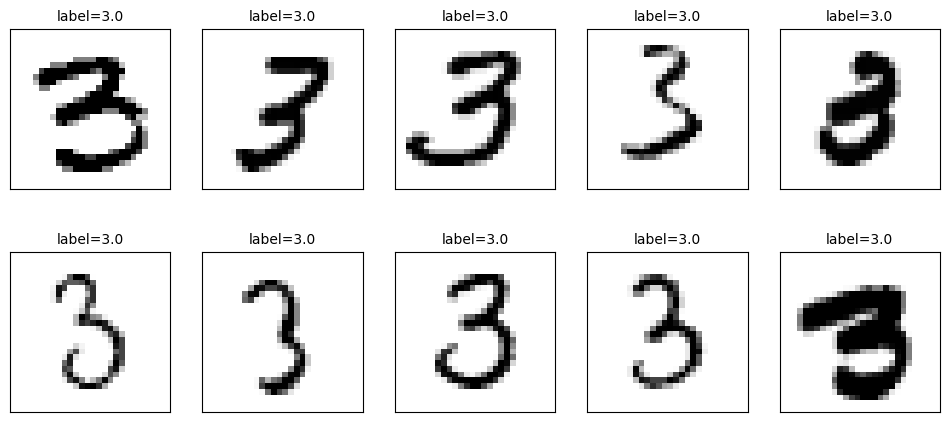

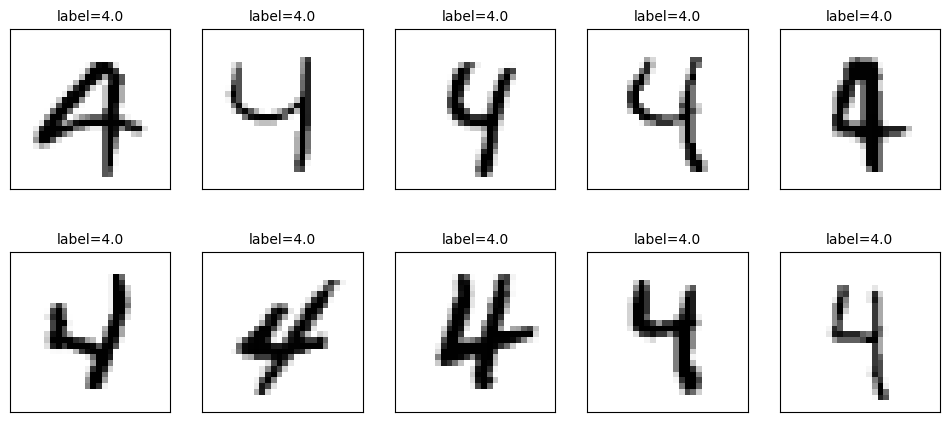

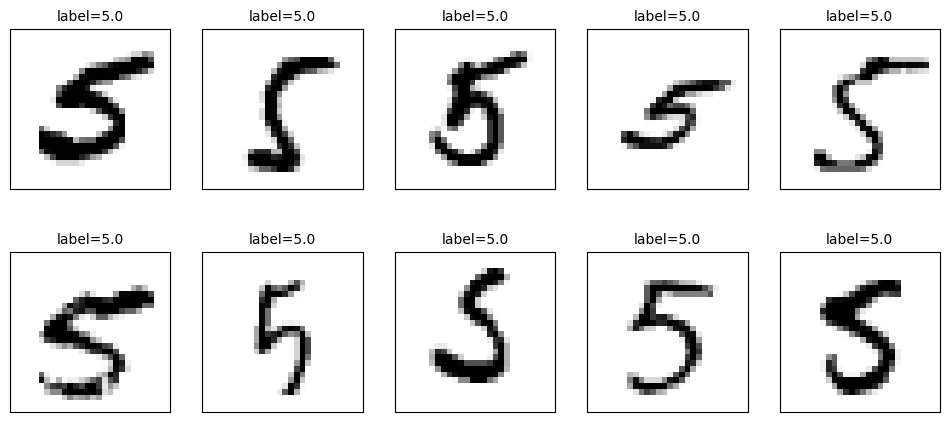

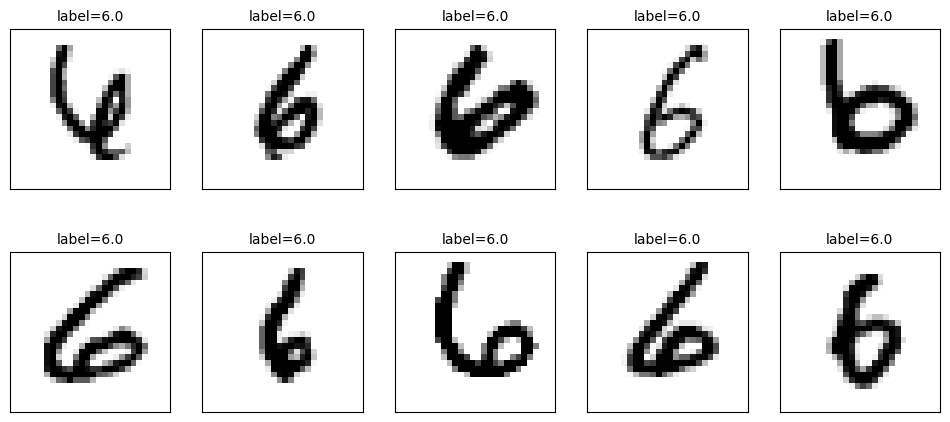

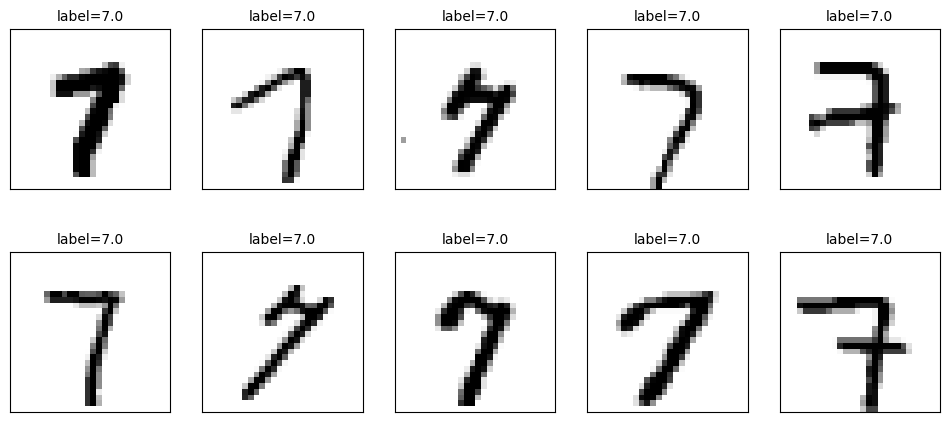

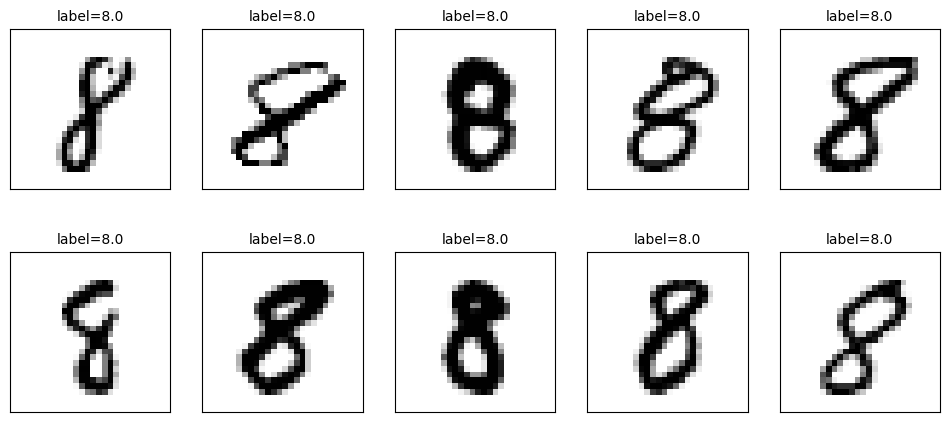

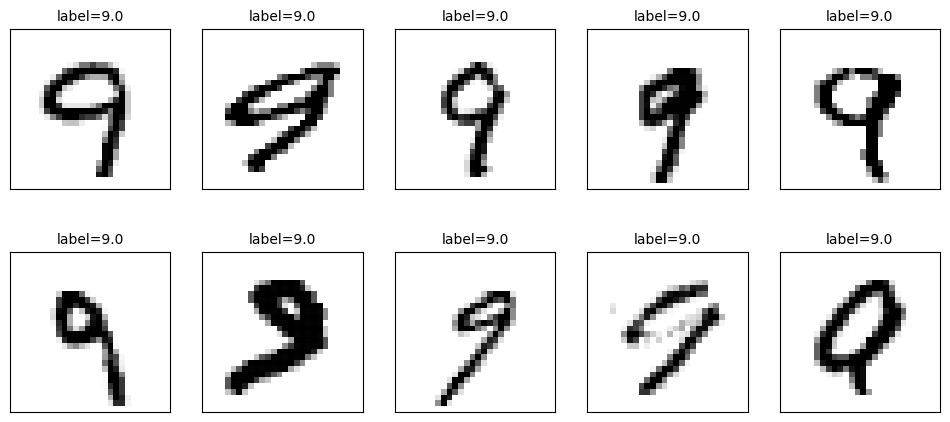

In [ ]:
for i in range(0,10):
  plot_images_labels_prediction(x_Train_data[x_Train_data['digital'] == i].loc[:,np.arange(0, 784)], x_Train_data[x_Train_data['digital'] == i].loc[:,['digital']],[],0,)

# Handwritten Digits and a Simple Algorithm(Mean)

### 透過 training set 取得手寫數字0~9的平均值陣列
### 將 testing set 每一張手寫數字與0~9平均值陣列比對，取最小的2norm，預測該張手寫數字代表的數字

In [ ]:
def getMeanDigitalTable(x_Data, y_Data):
    df = pd.DataFrame(x_Data)
    df['digital'] = y_Data

    # 計算每個數字類別的平均像素（0~255）
    mean_table = df.groupby('digital').mean()

    # 加上第784欄作為標籤欄位
    mean_table[784] = mean_table.index

    # 重新排序欄位，讓標籤在最後
    mean_table = mean_table[np.append(np.arange(0, 784), 784)]

    return mean_table.reset_index(drop=True)

In [ ]:
x_Train_mean = getMeanDigitalTable(x_Train, y_Train)
x_Train_mean

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,2.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,3.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,4.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,5.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,6.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003091,0.001123,0.000324,0.000458,0.000081,0.0,0.0,0.0,0.0,7.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,8.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000834,0.000690,0.000335,0.000144,0.000000,0.0,0.0,0.0,0.0,9.0


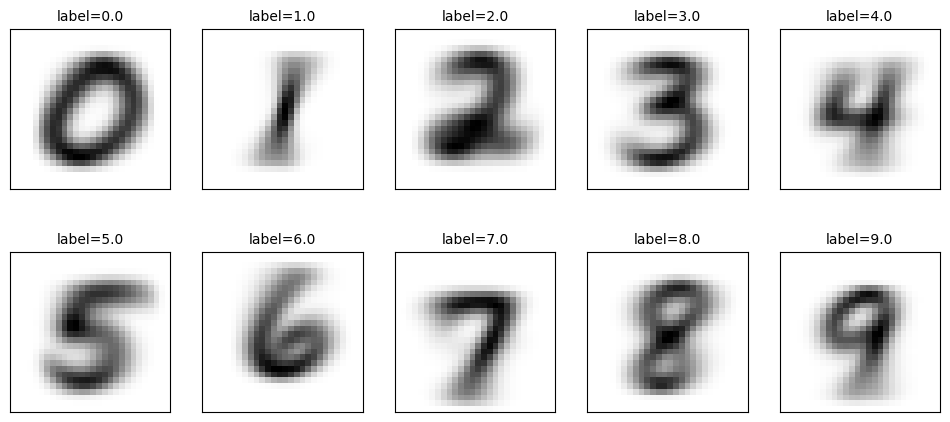

In [ ]:
# Show digits of mean
plot_images_labels_prediction(x_Train_mean.loc[:,np.arange(0, 784)], x_Train_mean.loc[:,[784]],[],0,10)

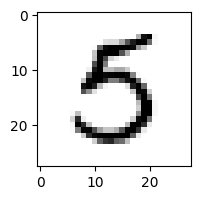

In [ ]:
# Test dataset
plot_image(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 784)].values[0].reshape([28, 28]))

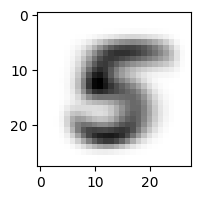

In [ ]:
# Mean
plot_image(x_Train_mean.iloc[5, np.arange(0, 784)].values.reshape([28, 28]))

In [ ]:
# @title
# norm2(x_Test_data.iloc[2, np.arange(0, 256)].values.reshape([16, 16]), x_Train_mean.iloc[2, np.arange(0, 256)].values.reshape([16, 16]))
# Get 2-norm of test_data_digit_8 and train_data_mean_digit_3
norm2(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 784)].values[0].reshape([28, 28]), x_Train_mean.iloc[5, np.arange(0, 784)].values.reshape([28, 28]))

4.239482622341015

In [ ]:
df_means = pd.DataFrame(np.zeros((1,10)))
for i in range(10):
  df_means[i] = norm2(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 784)].values[0].reshape([28, 28]), x_Train_mean.iloc[i, np.arange(0, 784)].values.reshape([28, 28]))
  df_means.columns = np.arange(10)
  df_means.index = ['residual value with digit 5']
df_means

,0,1,2,3,4,5,6,7,8,9
residual value with digit 5,3.925138,5.886107,6.430564,4.118207,6.08399,4.239483,6.132889,5.409705,5.714572,5.621533


In [ ]:
print(f"Minimal residual value= {df_means.min().min()}"
      f"which is digit {df_means.min().idxmin()}")

Minimal residual value= 3.925138232902098which is digit 0


In [ ]:
# @title
# Get 2-norm of test_data_digit_8 and train_data_mean_digit_8
np.linalg.norm(x_Test_data[x_Test_data['digital'] == 3].loc[:,np.arange(0, 784)].values[0] - x_Train_mean.iloc[3, np.arange(0, 784)].values, 2)

np.float64(6.190721663419837)

In [ ]:
# @title
x_Test_data.shape

(14000, 785)

In [ ]:
def simpleAlgorithm(x_Test_data, x_Train_mean):
  total = x_Test_data.shape[0]
  # isSuccess = 0
  # isError = 0
  result = np.zeros((total, 1))
  result_residual = np.zeros(total)
  result_residual_list = []

  for i in range(0, total):
    normList = np.zeros((1, 10))

    for j in range(0,10):
        residual_list = np.ones((10))

        normValue = norm2(x_Test_data.iloc[i, np.arange(0, 784)].values.reshape([28, 28]), x_Train_mean.iloc[j, np.arange(0, 784)].values.reshape([28, 28]))
        normList[0][j] = normValue
    prediction = np.where(normList == np.amin(normList))
    result[i][0] = int(prediction[1][0])
    result_residual[i] = np.amin(normList)
    result_residual_list.append(normList[0])

  tempPd = pd.concat([x_Test_data, pd.DataFrame(result, columns=['prediction'])], axis=1)
  x_Test_Prediction = pd.concat([tempPd, pd.DataFrame(result_residual, columns=['residual'])], axis=1)
  x_Test_result = x_Test_Prediction[x_Test_Prediction['digital'] == x_Test_Prediction['prediction']].shape[0]/x_Test_Prediction.shape[0]

  return x_Test_Prediction, x_Test_result, result_residual_list

In [ ]:
# x_Test_Prediction, x_Test_result, result_Test_residual = compareAlgorithm(x_Test_data, x_Train_mean)
x_Test_Prediction, x_Test_result, result_Test_residual = simpleAlgorithm(x_Test_data, x_Train_mean)

In [ ]:
x_Test_Prediction[x_Test_Prediction['prediction'] != x_Test_Prediction['digital']].shape[0]

3598

In [ ]:
print("準確率為 :", x_Test_result)

準確率為 : 0.743


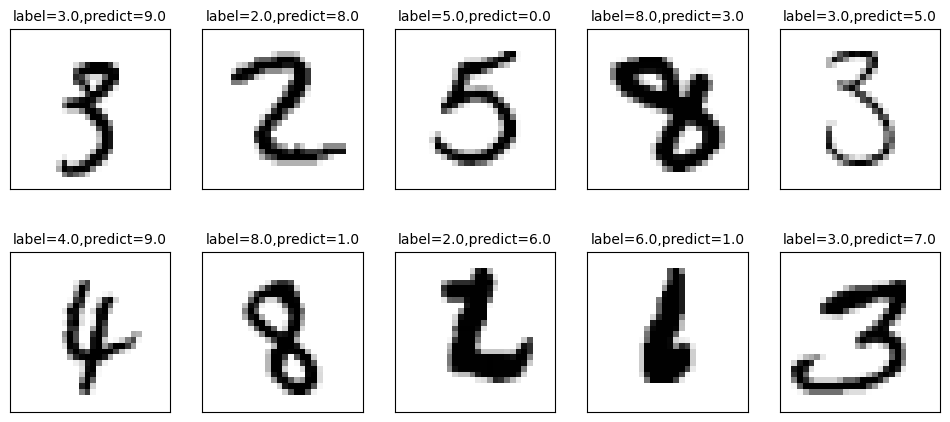

In [ ]:
errorList = x_Test_Prediction[x_Test_Prediction['digital'] != x_Test_Prediction['prediction']]

plot_images_labels_prediction(errorList.iloc[:,np.arange(0, 784)], errorList.iloc[:,[784]], errorList.iloc[:,[785]],0,10)

In [ ]:
# 計算每個數字的總預測數
totalCounts = x_Test_Prediction['digital'].value_counts().sort_index().rename('totalCounts')

# 計算每個數字的錯誤數
errorCounts = errorList['digital'].value_counts().sort_index().rename('errorCounts')

# 合併成一個 DataFrame，缺失值填 0
resultdf = pd.concat([totalCounts, errorCounts], axis=1).fillna(0)

# 計算成功數與成功率
resultdf['errorCounts'] = resultdf['errorCounts'].astype(int)
resultdf['successCounts'] = resultdf['totalCounts'] - resultdf['errorCounts']
resultdf['probability'] = resultdf['successCounts'] / resultdf['totalCounts']

# 依成功率排序
resultdf = resultdf.sort_values('probability', ascending=False).reset_index()
resultdf

,digital,totalCounts,errorCounts,successCounts,probability
0,1.0,1575,101,1474,0.935873
1,0.0,1381,219,1162,0.841419
2,7.0,1459,301,1158,0.793694
3,6.0,1375,309,1066,0.775273
4,4.0,1365,388,977,0.715751
5,3.0,1428,424,1004,0.703081
6,2.0,1398,428,970,0.693848
7,9.0,1391,454,937,0.673616
8,8.0,1365,468,897,0.657143
9,5.0,1263,506,757,0.599367


In [ ]:
# 計算每個 (digital, prediction) 的錯誤次數
temp = (
    errorList[['digital', 'prediction']]
    .groupby(['digital', 'prediction'])
    .size()
    .reset_index(name='counts')
)

# 建立空的錯誤預測矩陣：4 × 10
errorPrediction = np.zeros((4, 10))

# 對每個真實數字 i，找出最常見的兩個錯誤預測
for i in range(10):
  top_errors = (
      temp[temp['digital'] == i]
      .sort_values('counts', ascending=False)
      .head(2)
  )
  if len(top_errors) > 0:
      errorPrediction[0][i] = top_errors.iloc[0]['prediction']
      errorPrediction[1][i] = top_errors.iloc[0]['counts']
  if len(top_errors) > 1:
      errorPrediction[2][i] = top_errors.iloc[1]['prediction']
      errorPrediction[3][i] = top_errors.iloc[1]['counts']

# 包裝成 DataFrame
error_df = pd.DataFrame(errorPrediction, columns=np.arange(10))
error_df.index = ["1st wrongly predicted digit", "Qty", "2nd wrongly predicted digit", "Qty"]
error_df

,0,1,2,3,4,5,6,7,8,9
1st wrongly predicted digit,5.0,5.0,1.0,5.0,9.0,3.0,5.0,9.0,5.0,4.0
Qty,110.0,53.0,84.0,133.0,232.0,154.0,123.0,93.0,130.0,156.0
2nd wrongly predicted digit,6.0,2.0,6.0,8.0,6.0,1.0,4.0,1.0,3.0,7.0
Qty,44.0,18.0,73.0,87.0,43.0,126.0,60.0,61.0,121.0,84.0


## Digit 1

In [ ]:
components = np.where(y_Test == 1)[0]
components
x_Test_1 = x_Test[components, :]
y_Test_1 = np.full(x_Test_1.shape[0],1)

x_Test_1_data = pd.concat([pd.DataFrame(x_Test_1),pd.DataFrame(y_Test_1, columns=['digital'])], axis=1)
result_Test_1_list, y_Test_1_predict, result_Test_1_residual = simpleAlgorithm(x_Test_1_data, x_Train_mean)

In [ ]:
y_Test_1_predict

0.9358730158730159

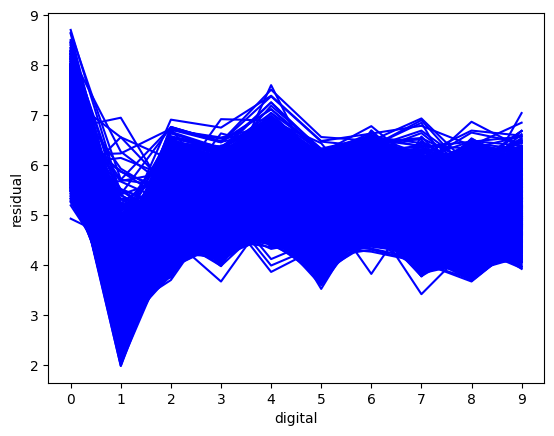

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_1.shape[0]):
    plt.plot(result_Test_1_residual[i],color = 'blue')

## Digit 0

In [ ]:
components = np.where(y_Test == 0)[0]
components
x_Test_0 = x_Test[components, :]
y_Test_0 = np.full(x_Test_0.shape[0],0)

x_Test_0_data = pd.concat([pd.DataFrame(x_Test_0),pd.DataFrame(y_Test_0, columns=['digital'])], axis=1)
result_Test_0_list, y_Test_0_predict, result_Test_0_residual = simpleAlgorithm(x_Test_0_data, x_Train_mean)

In [ ]:
y_Test_0_predict

0.8414192614047792

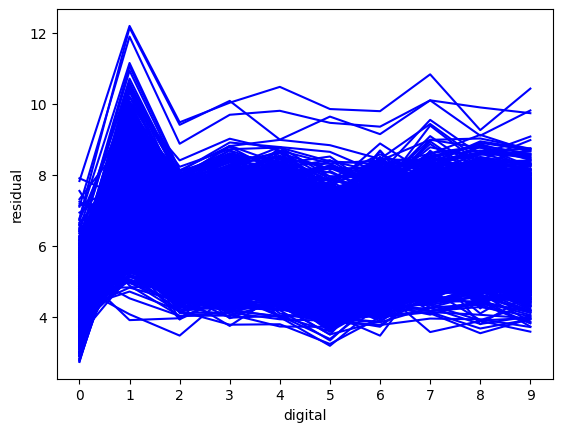

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_0.shape[0]):
  plt.plot(result_Test_0_residual[i],color = 'blue')

## Digit 8

In [ ]:
components = np.where(y_Test == 8)[0]
components
x_Test_8 = x_Test[components, :]
y_Test_8 = np.full(x_Test_8.shape[0],8)

x_Test_8_data = pd.concat([pd.DataFrame(x_Test_8),pd.DataFrame(y_Test_8, columns=['digital'])], axis=1)
result_Test_8_list, y_Test_8_predict, result_Test_8_residual = simpleAlgorithm(x_Test_8_data, x_Train_mean)

In [ ]:
y_Test_8_predict

0.6571428571428571

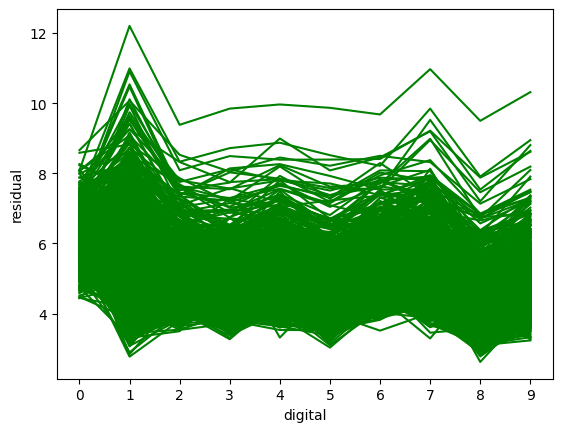

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_8.shape[0]):
    plt.plot(result_Test_8_residual[i],color = 'green')

## Digit 5

In [ ]:
components = np.where(y_Test == 5)[0]
components
x_Test_5 = x_Test[components, :]
y_Test_5 = np.full(x_Test_5.shape[0],5)

x_Test_5_data = pd.concat([pd.DataFrame(x_Test_5),pd.DataFrame(y_Test_5, columns=['digital'])], axis=1)
result_Test_5_list, y_Test_5_predict, result_Test_5_residual = simpleAlgorithm(x_Test_5_data, x_Train_mean)

In [ ]:
y_Test_5_predict

0.599366587490103

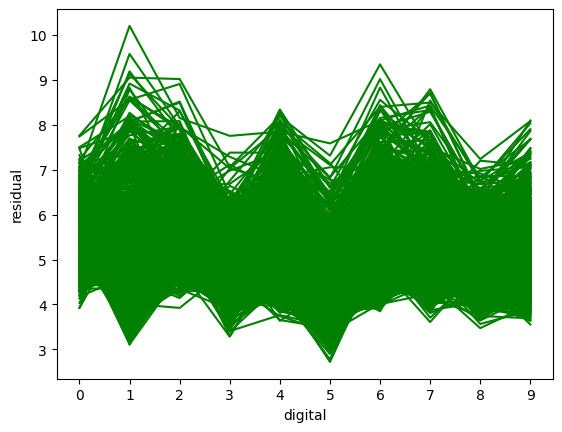

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_5.shape[0]):
    plt.plot(result_Test_5_residual[i],color = 'green')

## Predicted correctly between min and max 2-norm residual

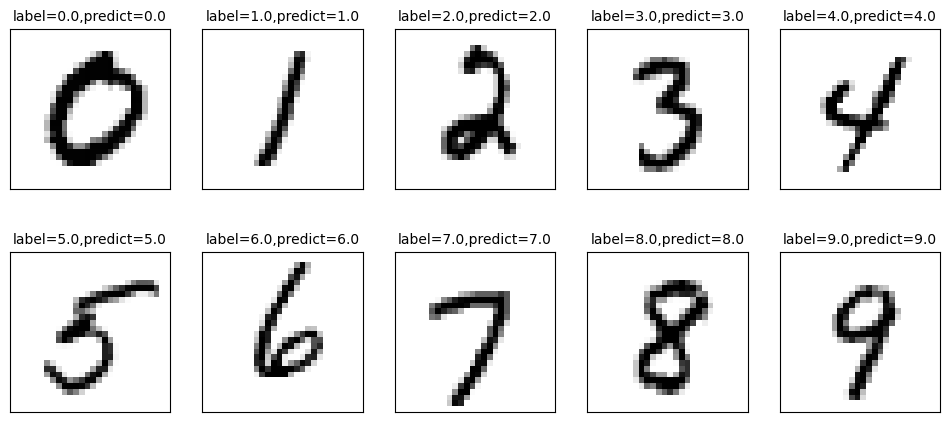

In [ ]:
minList = x_Test_Prediction[x_Test_Prediction['digital'] == x_Test_Prediction['prediction']].groupby('digital').agg({'residual': ['min']})
niceIndex = np.zeros(10)

for i in range(0,10):
  digitalList = x_Test_Prediction[x_Test_Prediction['digital'] == i]
  niceIndex[i] = int(digitalList[digitalList['residual'] == minList['residual']['min'][i]].index.values[0])

niceList = x_Test_Prediction.iloc[x_Test_Prediction.index.get_indexer(niceIndex)]
plot_images_labels_prediction(niceList.iloc[:,np.arange(0, 784)], niceList.iloc[:,[784]], niceList.iloc[:,[785]],0,10)

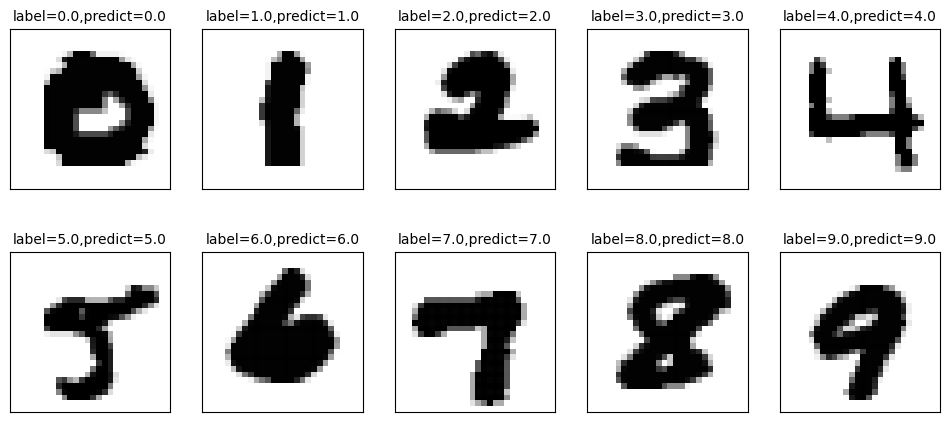

In [ ]:
maxList = x_Test_Prediction[x_Test_Prediction['digital'] == x_Test_Prediction['prediction']].groupby('digital').agg({'residual': ['max']})
uglyIndex = np.zeros(10)

for i in range(0,10):
    digitalList = x_Test_Prediction[x_Test_Prediction['digital'] == i]
    uglyIndex[i] = int(digitalList[digitalList['residual'] == maxList['residual']['max'][i]].index.values[0])

uglyList = x_Test_Prediction.iloc[x_Test_Prediction.index.get_indexer(uglyIndex)]
plot_images_labels_prediction(uglyList.iloc[:,np.arange(0, 784)], uglyList.iloc[:,[784]], uglyList.iloc[:,[785]],0,10)

## Test with my own data

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
  img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r")
  x_son1[i,:] = (np.array(img)/255).flatten()

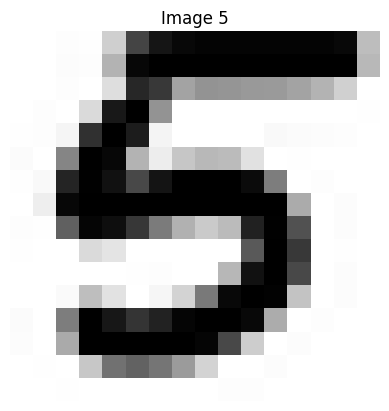

In [ ]:
# plt.imshow(img, cmap="gray")
plt.imshow(x_son1[5,:].reshape(16,16), cmap="binary")
plt.title(f"Image {5}")
plt.axis('off')
plt.show()

In [ ]:
x_son1_data = pd.concat([pd.DataFrame(x_son1),pd.DataFrame(y_son1, columns=['digital'])], axis=1)

In [ ]:
x_son1_Prediction, x_son1_result, result_son1_residual = simpleAlgorithm(x_son1_data, x_Train_mean)
x_son1_result

0.4

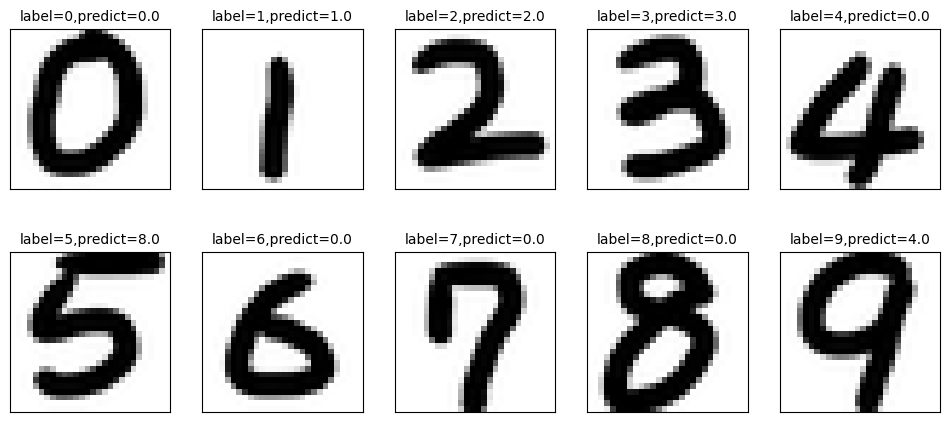

In [ ]:
plot_images_labels_prediction(x_son1_Prediction.iloc[:,np.arange(0, 784)], x_son1_Prediction.iloc[:,[784]], x_son1_Prediction.iloc[:,[785]],0,10)

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
  img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
  x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_data = pd.concat([pd.DataFrame(x_son2),pd.DataFrame(y_son2, columns=['digital'])], axis=1)

In [ ]:
x_son2_Prediction, x_son2_result, result_son2_residual = simpleAlgorithm(x_son2_data, x_Train_mean)
x_son2_result

0.3

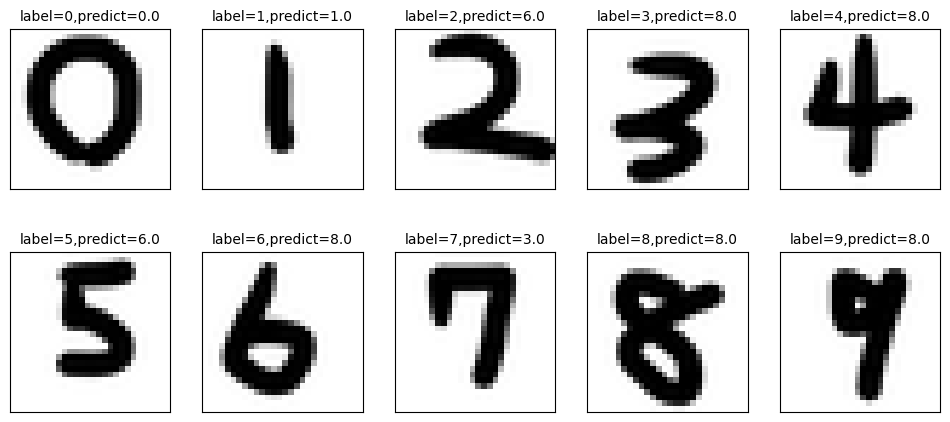

In [ ]:
plot_images_labels_prediction(x_son2_Prediction.iloc[:,np.arange(0, 784)], x_son2_Prediction.iloc[:,[784]], x_son2_Prediction.iloc[:,[785]],0,10)

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
  img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
  x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_data = pd.concat([pd.DataFrame(x_son3),pd.DataFrame(y_son3, columns=['digital'])], axis=1)

In [ ]:
x_son3_Prediction, x_son3_result, result_son3_residual = simpleAlgorithm(x_son3_data, x_Train_mean)
x_son3_result

0.1

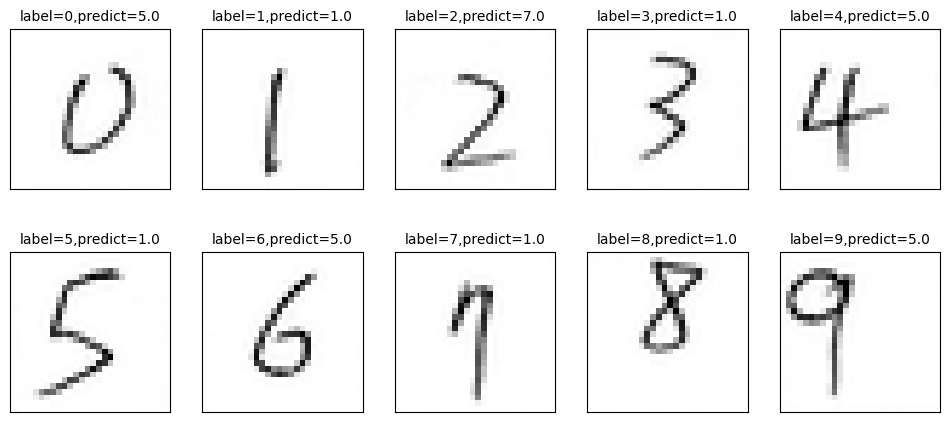

In [ ]:
plot_images_labels_prediction(x_son3_Prediction.iloc[:,np.arange(0, 784)], x_son3_Prediction.iloc[:,[784]], x_son3_Prediction.iloc[:,[785]],0,10)

In [ ]:
# @title
# Record all the results
overall_pred_res("Mean", [x_Test_result, x_son1_result, x_son2_result])

# Classification Using SVD Bases

In [ ]:
def getUList(x_Data, y_Data):
  # We now normalize all values between 0 and 1 and we now flatten the 16 × 16 images into vectors of size 784.

  x_Data = x_Data.astype('float32') / 255 if x_Data.max() > 1 else x_Data.astype('float32')
  x_Data = x_Data.reshape((len(x_Data), np.prod(x_Data.shape[1:])))
  x_Data = x_Data.T

  #  we now partition the x_train based on the ten classes and store in a list.
  x_list = []

  for k in range(10):
    components = np.where(y_Data == k)[0]
    x_list.append(x_Data[:, components])

  # we now create a svd basis for each digit data samples.
  U_list = []

  for k in range(10):
    U, S, V = np.linalg.svd(x_list[k])
    U_list.append(U)

  return U_list


def svdAlgorithm (x_Data, y_Data, U_list,basis):
  # We now normalize all values between 0 and 1 and we now flatten the 16 × 16 images into vectors of size 784.
  x_Data = x_Data.astype('float32') / 255 if x_Data.max() > 1 else x_Data.astype('float32')
  x_Data = x_Data.reshape((len(x_Data), np.prod(x_Data.shape[1:])))
  x_Data = x_Data.T

  # we now select the dominant orthogonal basis and project the digits on the reduced basis to compute the least square projection error.
  result_mse = []
  result_residual = []

  for r in range(basis):
    n_Data = x_Data.shape[1]
    y_predict = np.ones(n_Data)
    result_single = np.ones(n_Data)

    for i in range(0, n_Data):
      z = x_Data[:, i]
      residual_list = np.ones(10)

      for j in range(10):
        U_k = U_list[j][:, :r+1]
        # residual = np.linalg.norm(z - np.dot(U_k, np.dot(U_k.T, z)),2)/np.linalg.norm(z,2)
        residual = np.linalg.norm(z - U_k @ (U_k.T @ z),2)/np.linalg.norm(z,2)
        residual_list[j] = residual

      y_predict[i] = np.argmin(residual_list)

      if r == basis-1:
        result_residual.append(residual_list)
        result_single[i] = np.amin(residual_list)

    result_mse.append(np.mean((y_Data/1.0 - y_predict/1.0) ** 2))

  x_Data_list = pd.concat([pd.DataFrame(x_Data.T),pd.DataFrame(y_Data, columns=['actual'])], axis=1)
  result_List = pd.concat([x_Data_list, pd.DataFrame(y_predict, columns=['prediction'])], axis=1)
  result_List = pd.concat([result_List, pd.DataFrame(result_single, columns=['residual'])], axis=1)

  result_predict = result_List[result_List['actual'] == result_List['prediction']].shape[0]/result_List.shape[0]

  return result_List, y_predict, result_predict, result_residual, result_mse

In [ ]:
U_list = getUList(x_Train, y_Train)

In [ ]:
U_list[0].shape, len(U_list)

((784, 784), 10)

In [ ]:
def find_best_k(U_list, x_val, y_val, max_k=50):
    """
    自動 reshape + 自動處理 USPS SVD 子空間分類器的最佳 k 搜尋
    x_val: 可以是 (N, 784) 或 (784, N) 或 (N, 16, 16)
    y_val: shape = (N,)
    """

    # --- Step 1: 自動 reshape x_val 成 (784, N) ---
    if x_val.ndim == 3:  # (N, 16, 16)
        x_val = x_val.reshape(len(x_val), -1).T
    elif x_val.shape[0] != 784 and x_val.shape[1] == 784:
        x_val = x_val.T
    elif x_val.shape[0] != 784 and x_val.shape[1] != 784:
        raise ValueError("x_val 無法 reshape 成 784 維影像，請確認資料格式")

    # 現在 x_val shape = (784, N)
    N = x_val.shape[1]

    # --- Step 2: y_val reshape ---
    y_val = np.array(y_val).reshape(-1)
    if len(y_val) != N:
        raise ValueError("x_val 與 y_val 的樣本數不一致")

    # --- Step 3: 搜尋最佳 k ---
    best_k = None
    best_acc = 0

    for k in range(1, max_k + 1):
        correct = 0

        for i in range(N):
            x = x_val[:, i]

            residuals = []
            for d in range(10):
                U = U_list[d][:, :k]  # (784, k)
                x_hat = U @ (U.T @ x)  # (784,)
                residuals.append(np.linalg.norm(x - x_hat))

            pred = np.argmin(residuals)
            if pred == y_val[i]:
                correct += 1

        acc = correct / N

        if acc > best_acc:
            best_acc = acc
            best_k = k

    return best_k, best_acc

In [ ]:
from sklearn.model_selection import train_test_split

x_train2, x_val, y_train2, y_val = train_test_split(
    x_Train, y_Train, test_size=0.2, random_state=42, stratify=y_Train
)
U_list2 = getUList(x_train2, y_train2)
best_k, best_acc = find_best_k(U_list2, x_val, y_val)
best_k, best_acc

(27, 0.9544642857142858)

In [ ]:
# Train dataset
result_Train_list, y_Train_predict, result_Train_predict, result_Train_residual, result_Train_mse = svdAlgorithm(x_Train, y_Train, U_list, 27)

In [ ]:
result_Train_predict

0.9581964285714286

In [ ]:
result_Train_mse

[np.float64(3.5655892857142857),
 np.float64(2.5077857142857143),
 np.float64(1.6785892857142857),
 np.float64(1.497625),
 np.float64(1.3458571428571429),
 np.float64(1.224),
 np.float64(1.092517857142857),
 np.float64(1.0325892857142858),
 np.float64(0.9849821428571428),
 np.float64(0.983),
 np.float64(0.9659107142857143),
 np.float64(0.9287321428571429),
 np.float64(0.8989285714285714),
 np.float64(0.8966607142857143),
 np.float64(0.8718392857142857),
 np.float64(0.8618035714285714),
 np.float64(0.8461607142857143),
 np.float64(0.8388214285714286),
 np.float64(0.8265714285714286),
 np.float64(0.7953035714285714),
 np.float64(0.7855178571428572),
 np.float64(0.7820178571428571),
 np.float64(0.7594107142857143),
 np.float64(0.7713392857142857),
 np.float64(0.7672142857142857),
 np.float64(0.7704642857142857),
 np.float64(0.7715178571428571)]

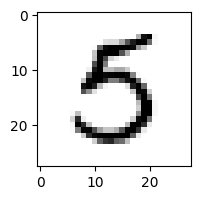

In [ ]:
plot_image(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 784)].values[0].reshape([28, 28]))
z = x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 784)].iloc[0].values


In [ ]:
# @title
type(U_list), len(U_list[5])

(list, 784)

k=27

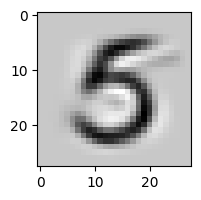

np.float64(0.35558524158005805)

In [ ]:
U_k = U_list[5][:, :27]
plot_image(np.dot(U_k, np.dot(U_k.T, z)).reshape([28, 28]))
residual = np.linalg.norm(z - U_k @ (U_k.T @ z),2)/np.linalg.norm(z,2)
residual

k=1

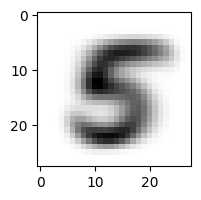

np.float64(0.6957472201414677)

In [ ]:
U_k = U_list[5][:, :1]
plot_image((U_k @ (U_k.T @ z)).reshape([28, 28]))
residual = np.linalg.norm(z - U_k @ (U_k.T @ z),2)/np.linalg.norm(z,2)
residual

Residual of Z=5 and digit=0-9(k=27)

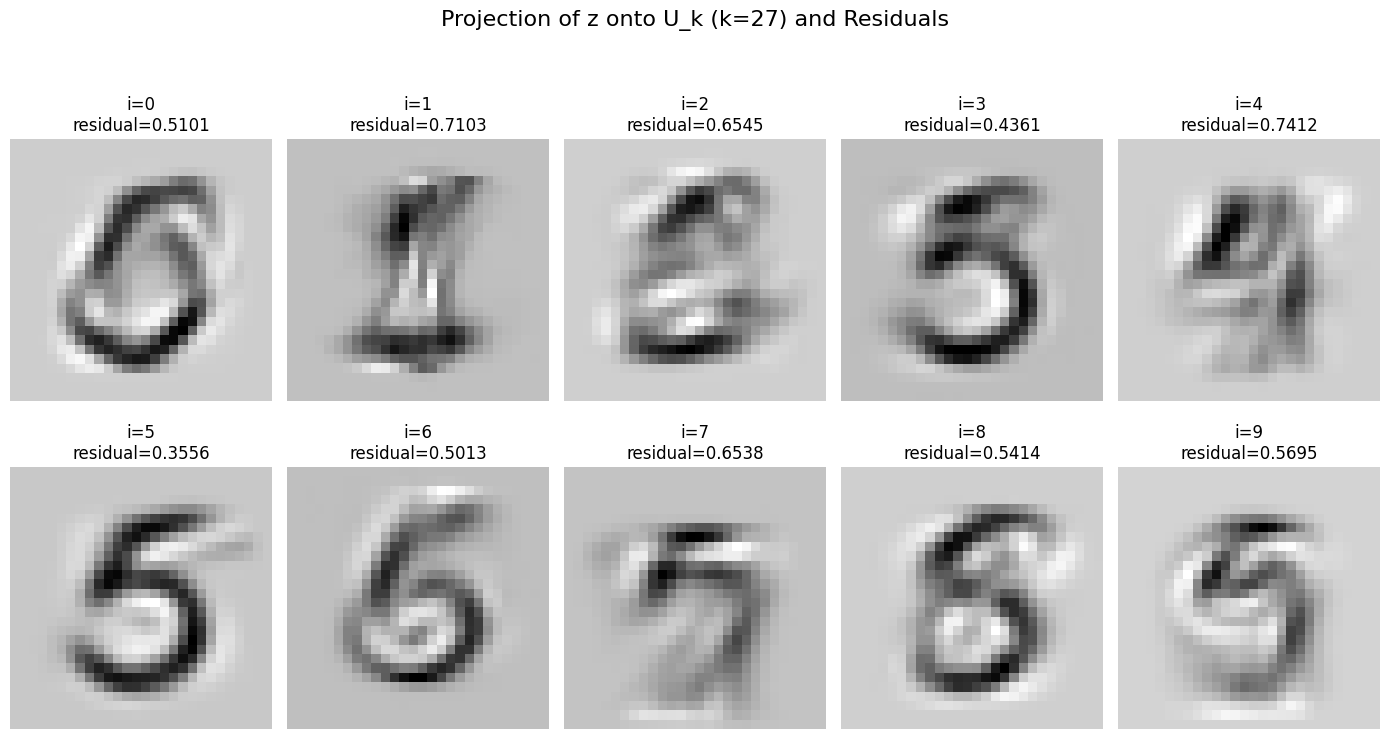

In [ ]:
k = 27
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle(f"Projection of z onto U_k (k={k}) and Residuals", fontsize=16)

for i in range(10):
  U_k = U_list[i][:, :k]  # 取前 k 個主成分
  z_proj = U_k @ (U_k.T @ z) # 投影到子空間再投影回原空間
  residual = np.linalg.norm(z - z_proj) / np.linalg.norm(z)

  ax = axes[i // 5, i % 5]
  ax.imshow(z_proj.reshape(28, 28), cmap='binary')
  ax.set_title(f"i={i}\nresidual={residual:.4f}")
  ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Residual of Z=5 and digit=0-9(k=1)

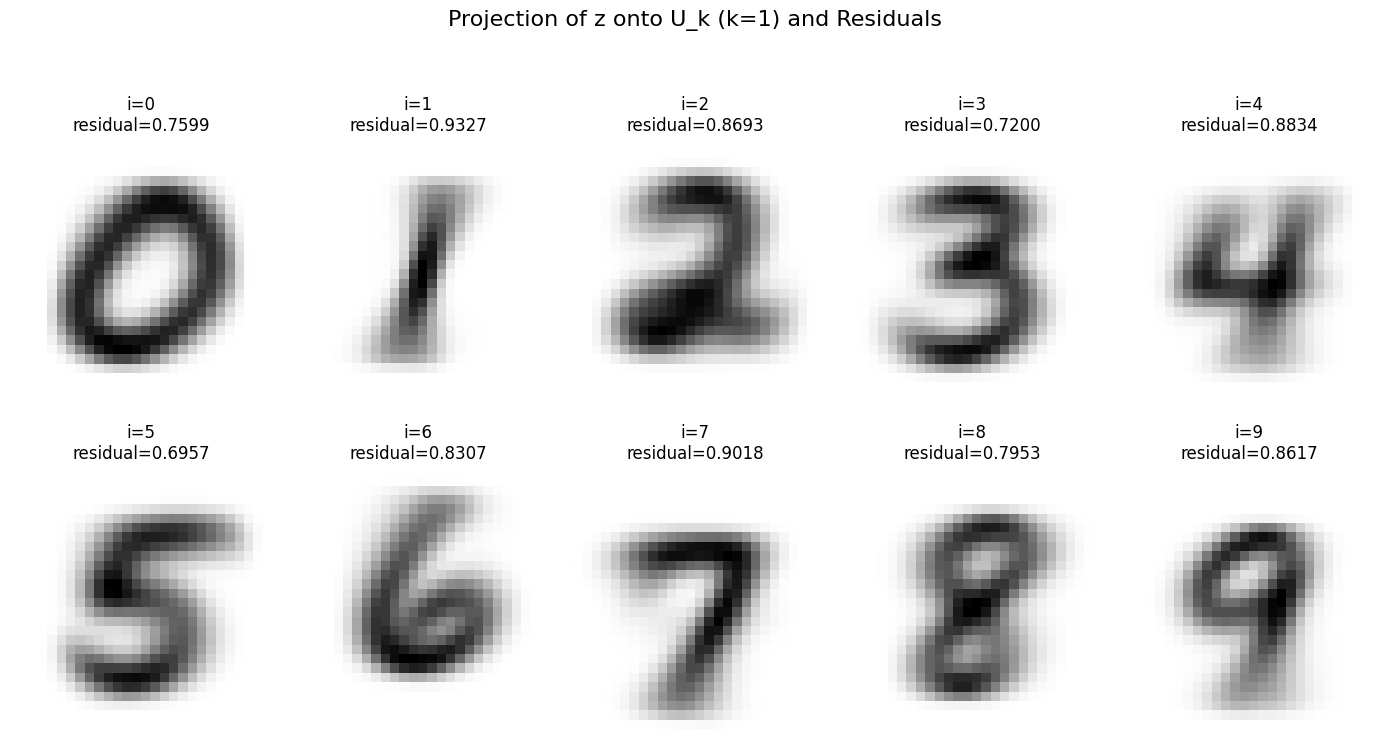

In [ ]:
k = 1
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle(f"Projection of z onto U_k (k={k}) and Residuals", fontsize=16)

for i in range(10):
  U_k = U_list[i][:, :k]  # 取前 k 個主成分
  z_proj = U_k @ (U_k.T @ z)  # 投影到子空間再投影回原空間
  residual = np.linalg.norm(z - z_proj) / np.linalg.norm(z)

  ax = axes[i // 5, i % 5]
  ax.imshow(z_proj.reshape(28, 28), cmap='binary')
  ax.set_title(f"i={i}\nresidual={residual:.4f}")
  ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Residual of Z=5 and digit=0-9(k=30)

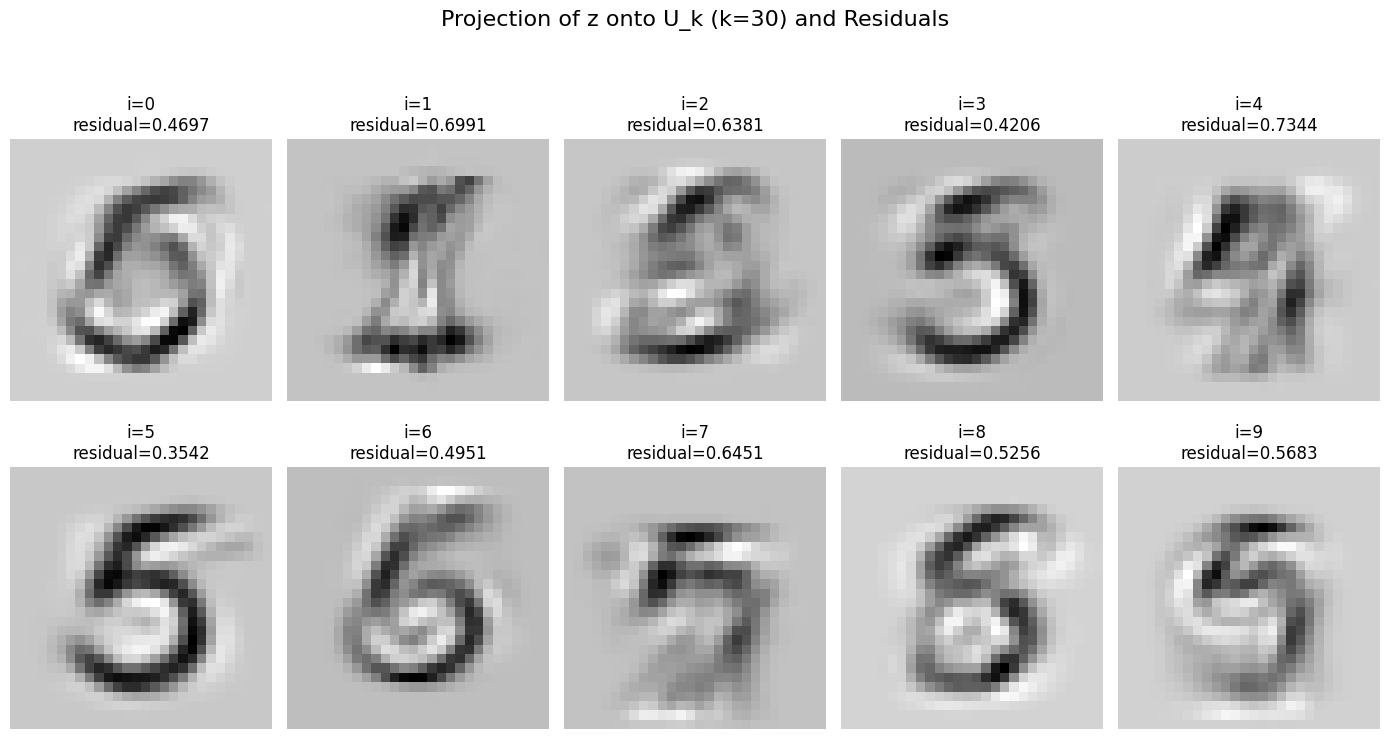

In [ ]:
k = 30
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle(f"Projection of z onto U_k (k={k}) and Residuals", fontsize=16)

for i in range(10):
  U_k = U_list[i][:, :k]  # 取前 k 個主成分
  # z_proj = np.dot(U_k, np.dot(U_k.T, z))  # 投影到子空間再投影回原空間
  z_proj = U_k @ (U_k.T @ z)
  residual = np.linalg.norm(z - z_proj) / np.linalg.norm(z)

  ax = axes[i // 5, i % 5]
  ax.imshow(z_proj.reshape(28, 28), cmap='binary')
  ax.set_title(f"i={i}\nresidual={residual:.4f}")
  ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

In [ ]:
result_Train_list[result_Train_list['prediction'] != result_Train_list['actual']].shape[0]

2341

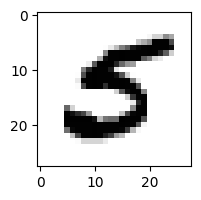

In [ ]:
img = x_Train[y_Train == 5][0]
plot_image(img.reshape([28, 28]))

In [ ]:
# result_Train_residual[7290]
result_Train_residual[np.where(y_Train == 5)[0][0]]

array([0.50147265, 0.73129183, 0.54163861, 0.40989456, 0.70121616,
       0.28714582, 0.5960691 , 0.71456778, 0.57101989, 0.69917393])

Text(0.5, 0, 'number of basis')

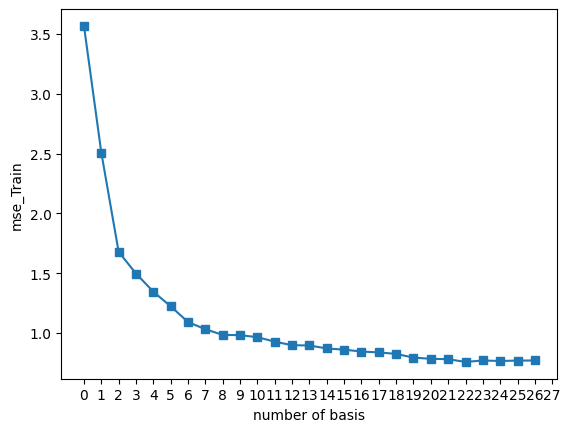

In [ ]:
plt.plot(result_Train_mse,'s-')
plt.xticks(range(0,28))
plt.ylabel('mse_Train')
plt.xlabel('number of basis')

In [ ]:
# Test dataset
result_Test_list, y_Test_predict, result_Test_predict, result_Test_residual, result_Test_mse = svdAlgorithm(x_Test, y_Test, U_list, 27)

In [ ]:
result_Test_predict

0.9548571428571428

In [ ]:
result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']].shape[0]

632

Predict wrong

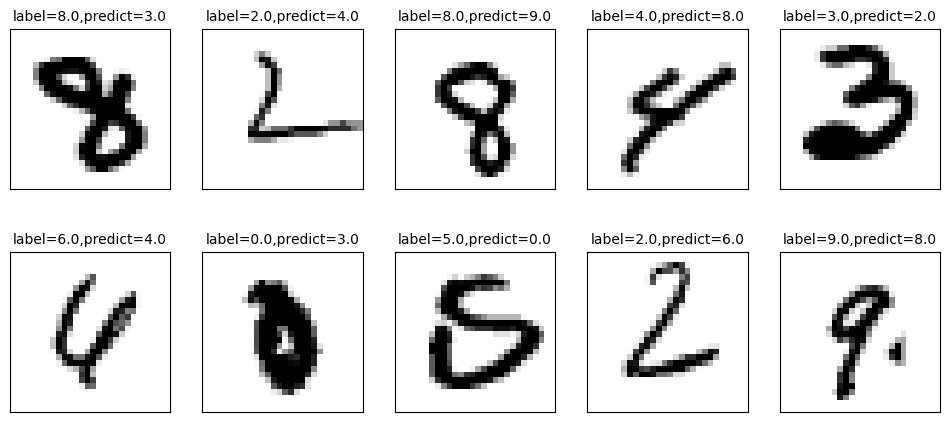

In [ ]:
errorList = result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']]

errorList.shape

plot_images_labels_prediction(errorList.iloc[:,np.arange(0, 784)], errorList.iloc[:,[784]], errorList.iloc[:,[785]],0,10)

In [ ]:
# 計算每個 (digital, prediction) 的錯誤次數
temp = (
    errorList[['actual', 'prediction']]
    .groupby(['actual', 'prediction'])
    .size()
    .reset_index(name='counts')
)

# 建立空的錯誤預測矩陣：4 × 10
errorPrediction = np.zeros((4, 10))

# 對每個真實數字 i，找出最常見的兩個錯誤預測
for i in range(10):
  top_errors = (
      temp[temp['actual'] == i]
      .sort_values('counts', ascending=False)
      .head(2)
  )
  if len(top_errors) > 0:
      errorPrediction[0][i] = top_errors.iloc[0]['prediction']
      errorPrediction[1][i] = top_errors.iloc[0]['counts']
  if len(top_errors) > 1:
      errorPrediction[2][i] = top_errors.iloc[1]['prediction']
      errorPrediction[3][i] = top_errors.iloc[1]['counts']

# 包裝成 DataFrame
error_df = pd.DataFrame(errorPrediction, columns=np.arange(10))
error_df.index = ["1st wrongly predicted digit", "Qty", "2nd wrongly predicted digit", "Qty"]
error_df

,0,1,2,3,4,5,6,7,8,9
1st wrongly predicted digit,8.0,2.0,8.0,8.0,9.0,3.0,5.0,9.0,3.0,7.0
Qty,6.0,10.0,22.0,36.0,21.0,27.0,12.0,46.0,20.0,20.0
2nd wrongly predicted digit,1.0,7.0,7.0,0.0,1.0,8.0,0.0,2.0,1.0,3.0
Qty,4.0,6.0,13.0,14.0,8.0,19.0,8.0,10.0,19.0,14.0


In [ ]:
# 計算每個數字的總預測數
totalCounts = result_Test_list['actual'].value_counts().sort_index().rename('totalCounts')

# 計算每個數字的錯誤數
errorCounts = errorList['actual'].value_counts().sort_index().rename('errorCounts')

# 合併成一個 DataFrame，缺失值填 0
resultdf = pd.concat([totalCounts, errorCounts], axis=1).fillna(0)

# 計算成功數與成功率
resultdf['errorCounts'] = resultdf['errorCounts'].astype(int)
resultdf['successCounts'] = resultdf['totalCounts'] - resultdf['errorCounts']
resultdf['probability'] = resultdf['successCounts'] / resultdf['totalCounts']

# 依成功率排序
resultdf = resultdf.sort_values('probability', ascending=False).reset_index()
resultdf

,actual,totalCounts,errorCounts,successCounts,probability
0,0.0,1381,17,1364,0.987690
1,1.0,1575,22,1553,0.986032
2,6.0,1375,37,1338,0.973091
3,4.0,1365,50,1315,0.963370
4,2.0,1398,72,1326,0.948498
5,7.0,1459,78,1381,0.946539
6,9.0,1391,84,1307,0.939612
7,5.0,1263,80,1183,0.936659
8,3.0,1428,93,1335,0.934874
9,8.0,1365,99,1266,0.927473


Predict correctly with min residual

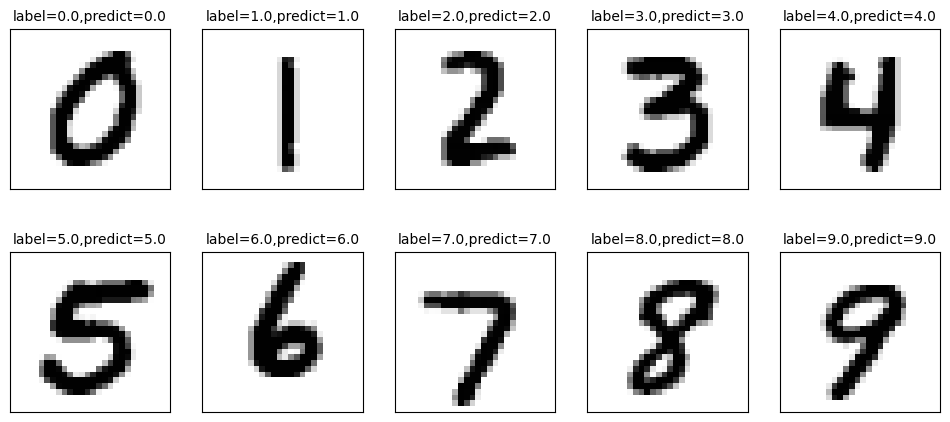

In [ ]:
minList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['min']})


niceIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    niceIndex[i] = int(digitalList[digitalList['residual'] == minList['residual']['min'][i]].index.values[0])

niceList = result_Test_list.iloc[result_Test_list.index.get_indexer(niceIndex)]

plot_images_labels_prediction(niceList.iloc[:,np.arange(0, 784)], niceList.iloc[:,[784]], niceList.iloc[:,[785]],0,10)

Predict correctly with max residual

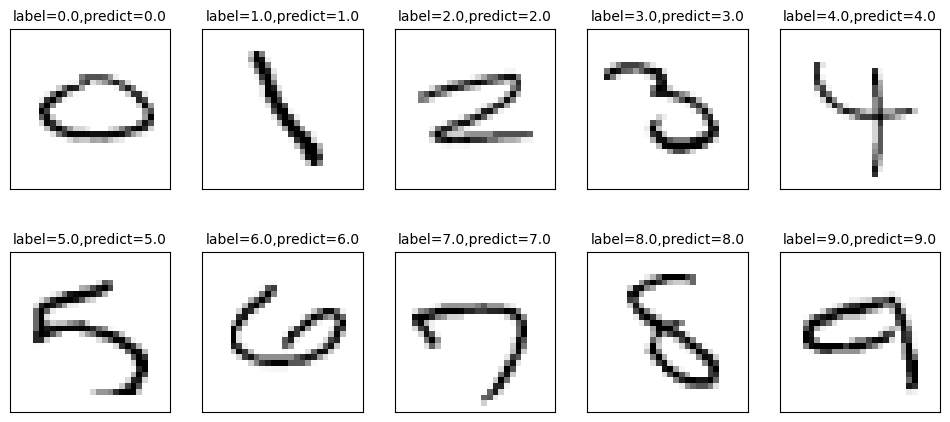

In [ ]:
maxList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['max']})

uglyIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    uglyIndex[i] = int(digitalList[digitalList['residual'] == maxList['residual']['max'][i]].index.values[0])

uglyList = result_Test_list.iloc[result_Test_list.index.get_indexer(uglyIndex)]

plot_images_labels_prediction(uglyList.iloc[:,np.arange(0, 784)], uglyList.iloc[:,[784]], uglyList.iloc[:,[785]],0,10)

In [ ]:
result_Test_residual[np.where(y_Test == 5)[0][0]]

array([0.51014501, 0.71026629, 0.65452784, 0.43605837, 0.74117416,
       0.35558522, 0.50132096, 0.65375113, 0.54136074, 0.56951559])

Text(0.5, 0, 'number of basis')

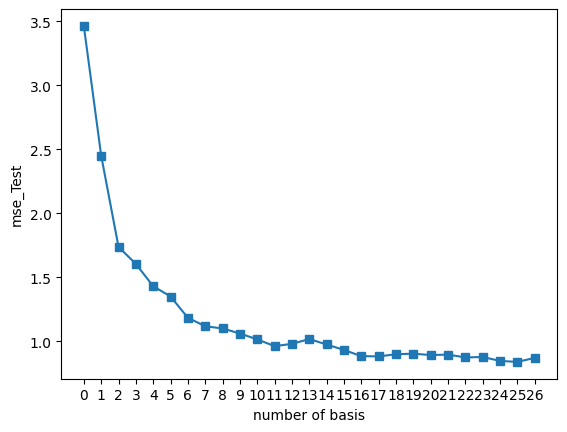

In [ ]:
plt.plot(result_Test_mse,'s-')
plt.xticks(range(0,27))
plt.ylabel('mse_Test')
plt.xlabel('number of basis')

Digit 0

In [ ]:
components = np.where(y_Test == 0)[0]
components
x_Test_0 = x_Test[components, :]
y_Test_0 = np.full(x_Test_0.shape[0],0)

In [ ]:
result_Test_0_list, y_Test_0_predict, result_Test_0_predict, result_Test_0_residual, result_Test_0_mse = svdAlgorithm(x_Test_0, y_Test_0, U_list, 27)

In [ ]:
result_Test_0_predict

0.9876900796524257

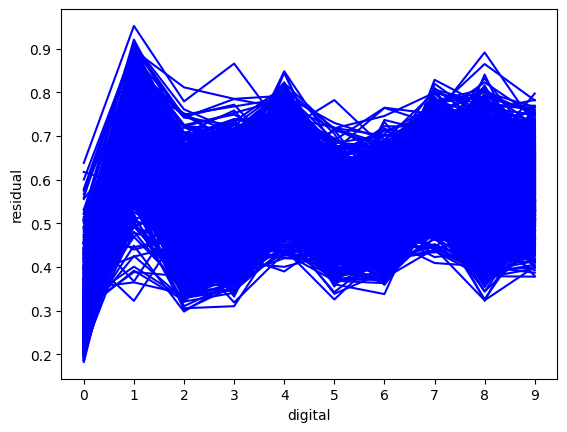

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_0.shape[0]):
    plt.plot(result_Test_0_residual[i],color = 'blue')

Digit 1

In [ ]:
components = np.where(y_Test == 1)[0]
components
x_Test_1 = x_Test[components, :]
y_Test_1 = np.full(x_Test_1.shape[0],1)

In [ ]:
result_Test_1_list, y_Test_1_predict, result_Test_1_predict, result_Test_1_residual, result_Test_1_mse = svdAlgorithm(x_Test_1, y_Test_1, U_list, 27)

In [ ]:
result_Test_1_predict

0.986031746031746

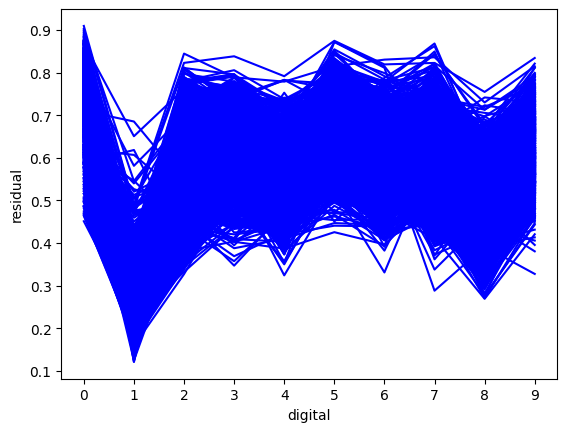

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_1.shape[0]):
    plt.plot(result_Test_1_residual[i],color = 'blue')

Digit 8

In [ ]:
components = np.where(y_Test == 8)[0]
components
x_Test_8 = x_Test[components, :]
y_Test_8 = np.full(x_Test_8.shape[0],8)

In [ ]:
result_Test_8_list, y_Test_8_predict, result_Test_8_predict, result_Test_8_residual, result_Test_8_mse = svdAlgorithm(x_Test_8, y_Test_8, U_list, 27)

In [ ]:
result_Test_8_predict

0.9274725274725275

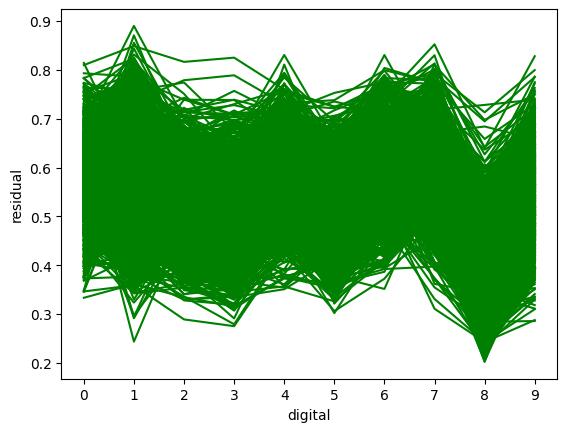

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_8.shape[0]):
    plt.plot(result_Test_8_residual[i],color = 'green')

Digit 3

In [ ]:
components = np.where(y_Test == 3)[0]
components
x_Test_3 = x_Test[components, :]
y_Test_3 = np.full(x_Test_3.shape[0],3)

In [ ]:
result_Test_3_list, y_Test_3_predict, result_Test_3_predict, result_Test_3_residual, result_Test_3_mse = svdAlgorithm(x_Test_3, y_Test_3, U_list, 27)

In [ ]:
result_Test_3_predict

0.9348739495798319

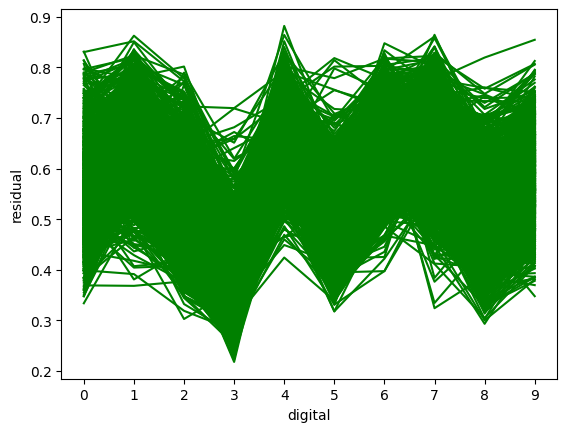

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_3.shape[0]):
    plt.plot(result_Test_3_residual[i], color = 'green')

My own data

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son1_list, y_son1_predict, result_son1_predict, result_son1_residual, result_son1_mse = svdAlgorithm(x_son1, y_son1, U_list, 27)
result_son1_predict

0.5

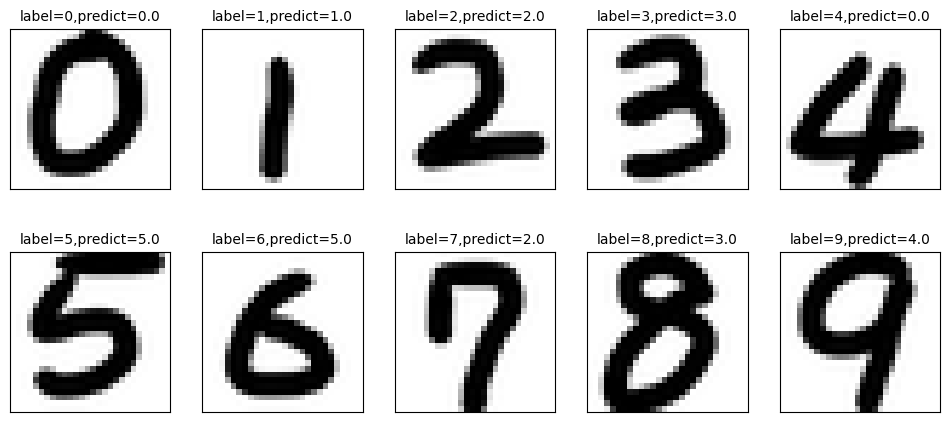

In [ ]:
plot_images_labels_prediction(result_son1_list.iloc[:,np.arange(0, 784)], result_son1_list.iloc[:,[784]], result_son1_list.iloc[:,[785]],0,10)

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
  img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
  x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son2_list, y_son2_predict, result_son2_predict, result_son2_residual, result_son2_mse = svdAlgorithm(x_son2, y_son2, U_list, 27)
result_son2_predict

0.7

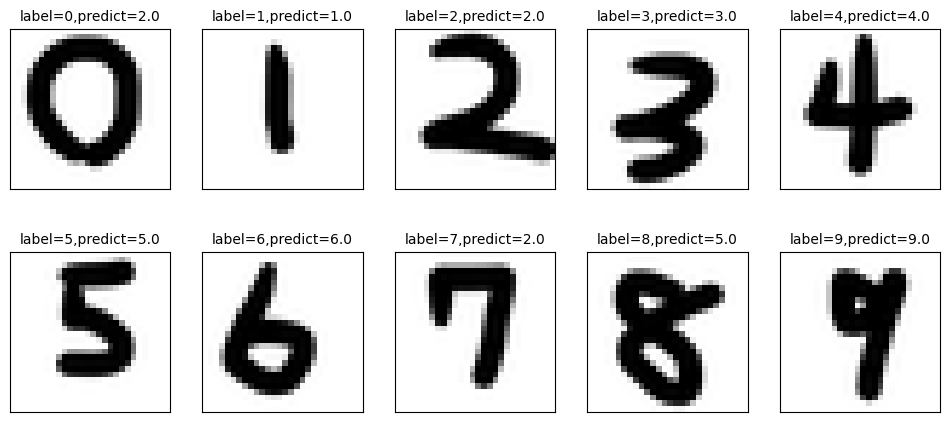

In [ ]:
plot_images_labels_prediction(result_son2_list.iloc[:,np.arange(0, 784)], result_son2_list.iloc[:,[784]], result_son2_list.iloc[:,[785]],0,10)

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
  img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
  x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son3_list, y_son3_predict, result_son3_predict, result_son3_residual, result_son3_mse = svdAlgorithm(x_son3, y_son3, U_list, 27)
result_son3_predict

0.5

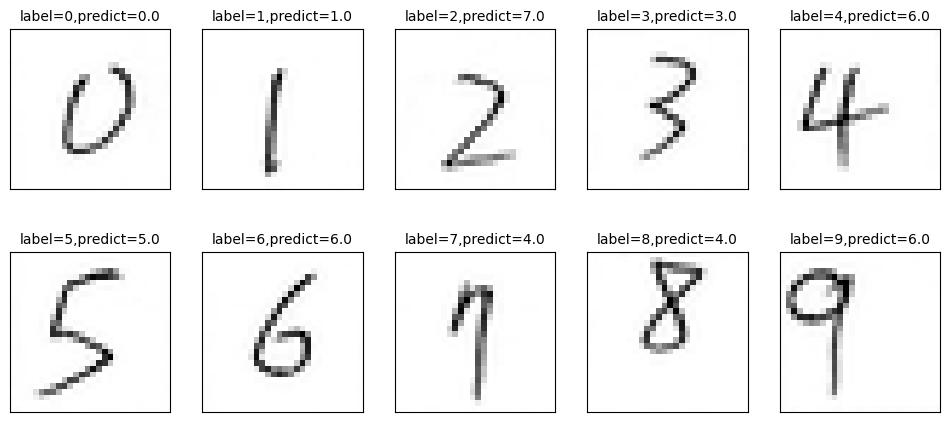

In [ ]:
plot_images_labels_prediction(result_son3_list.iloc[:,np.arange(0, 784)], result_son3_list.iloc[:,[784]], result_son3_list.iloc[:,[785]],0,10)

In [ ]:
# @title
# Record all the results
overall_pred_res("SVD", [result_Test_predict, result_son1_predict, result_son2_predict])

# Classification Using higher order SVD (HOSVD)

In [ ]:
!pip install tensorly

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 947.6 kB/s  0:00:072.6 kB/s eta 0:00:01:01

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
# @title
!pip install --upgrade tensorly

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
import tensorly as tl
from tensorly.decomposition import tucker

tl.set_backend('numpy')  # 可改為 'pytorch' 或 'tensorflow'

def getSandUList(x_Train, y_Train, img_shape=(28, 28), ranks=(28, 28, 10)):
    x_list = [x_Train[np.where(y_Train == k)[0]] for k in range(10)]

    S_list = []
    U_list = []

    for k in range(10):
        tensor = np.zeros((img_shape[0], img_shape[1], x_list[k].shape[0]))
        for i in range(x_list[k].shape[0]):
            tensor[:, :, i] = x_list[k][i].reshape(img_shape)

        # 使用 tensorly 的 Tucker 分解
        core, factors = tucker(tensor, tensor.shape) #(ranks))
        S_list.append(core)
        U_list.append(factors[:3])  # 保留 U1, U2, U3（空間維度）

    return S_list, U_list

def hosvdAlgorithm(x_Data, y_Data, S_list, U_list, basis, img_shape=(28, 28)):
    x_Data = x_Data.astype('float32') / 255 if x_Data.max() > 1 else x_Data.astype('float32')
    x_Data = x_Data.reshape((len(x_Data), np.prod(x_Data.shape[1:])))

    result_mse = []
    result_residual = []

    for r in range(basis):
        n_Data = x_Data.shape[0]
        y_predict = np.ones(n_Data)
        result_single = np.ones(n_Data)

        for i in range(n_Data):
            Z = x_Data[i].reshape(img_shape)
            residual_list = np.ones(10)

            for d in range(10):
                U1, U2, U3 = U_list[d]
                S = S_list[d]

                Sigma = np.zeros(img_shape)

                for j in range(r + 1):
                  if j < S.shape[2]:
                    Aj = U1 @ S[:, :, j] @ U2.T
                    Zj = np.tensordot(Z, Aj) / np.tensordot(Aj, Aj)
                    Sigma += Zj * Aj

                G = np.linalg.norm(Z - Sigma, "fro")
                residual_list[d] = G

            y_predict[i] = np.argmin(residual_list)

            if r == basis - 1:
                result_residual.append(residual_list)
                result_single[i] = np.min(residual_list)

        result_mse.append(np.mean((y_Data - y_predict) ** 2))

    x_Data_list = pd.concat([pd.DataFrame(x_Data), pd.DataFrame(y_Data, columns=['actual'])], axis=1)
    result_list = pd.concat([x_Data_list, pd.DataFrame(y_predict, columns=['prediction'])], axis=1)
    result_list = pd.concat([result_list, pd.DataFrame(result_single, columns=['residual'])], axis=1)
    result_prediction = (result_list['prediction'] == result_list['actual']).mean()

    return result_list, y_predict, result_prediction, result_residual, result_mse

Use digit=5 for trial

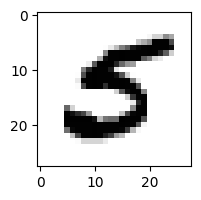

In [ ]:
plot_image(x_Train[y_Train == 5][0].reshape([28, 28]))

In [ ]:
components = np.where(y_Train == 5)[0]
components
x_Train_5 = x_Train[components, :]
y_Train_5 = np.full(x_Train_5.shape[0],5)

x_Train_5.shape

(5050, 784)

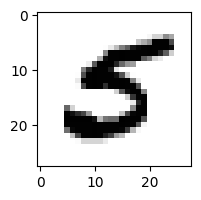

In [ ]:
tensor = np.zeros((28, 28, x_Train_5.shape[0]))

for i in range(x_Train_5.shape[0]):
    tensor[:,:,i] = x_Train_5[i][:].reshape([28, 28])

plot_image(tensor[:,:,0])

In [ ]:
# 使用 tensorly 進行 Tucker 分解
k=27
# core, factors = tucker(tensor, (16, 16, k), init='svd')
core, factors = tucker(tensor, tensor.shape, init='svd')

# core 對應原本的 S，factors 對應原本的 U（U1, U2, U3）
S = core
U = factors

In [ ]:
S.shape, U[0].shape, U[1].shape, U[2].shape

((28, 28, 5050), (28, 28), (28, 28), (5050, 5050))

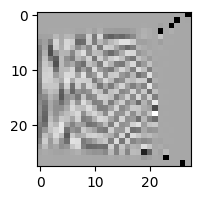

In [ ]:
plot_image(U[0])

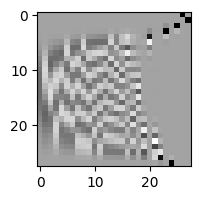

In [ ]:
plot_image(U[1])

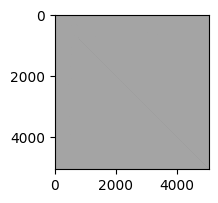

In [ ]:
# @title
plot_image(U[2])

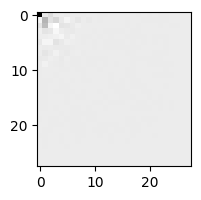

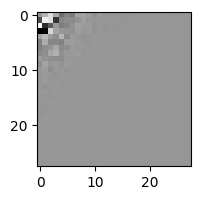

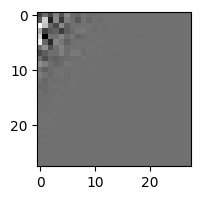

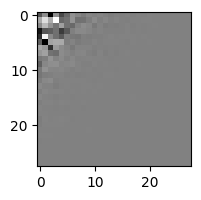

In [ ]:
plot_image(S[:,:,0])
plot_image(S[:,:,1])
plot_image(S[:,:,2])
plot_image(S[:,:,3])

hosvd_tensor vs ori tensor

$$
A_{\mathrm{hosvd}} = S \times_{1} U[0] \times_{2} U[1] \times_{3} U[2]
$$

In [ ]:
import torch as tc

A_hosvd = tc.einsum("abc,da,eb,fc->def", tc.as_tensor(S), tc.as_tensor(U[0]), tc.as_tensor(U[1]), tc.as_tensor(U[2]))

In [ ]:
hosvd_tensor = tc.Tensor.cpu(A_hosvd).detach().numpy()[:,:,:]

In [ ]:
tensor.shape, hosvd_tensor.shape

((28, 28, 5050), (28, 28, 5050))

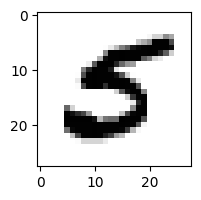

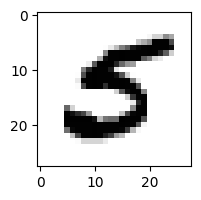

In [ ]:
plot_image(tensor[:,:,0])
plot_image(hosvd_tensor[:,:,0])

In [ ]:
error = np.linalg.norm(tensor - hosvd_tensor)
error

np.float64(1.4291391579056832e-12)

In [ ]:
relative_error = error / np.linalg.norm(tensor)
relative_error

np.float64(2.1743012017587374e-15)

Train dataset

In [ ]:
S_list, U_list = getSandUList(x_Train, y_Train)

In [ ]:
U1, U2, U3 = U_list[5]
S = S_list[5]
S.shape, U1.shape, U2.shape, U3.shape

((28, 28, 5050), (28, 28), (28, 28), (5050, 5050))

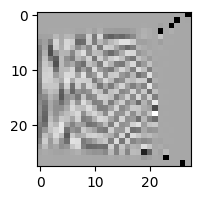

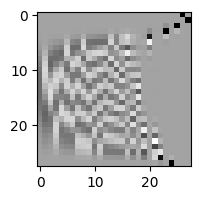

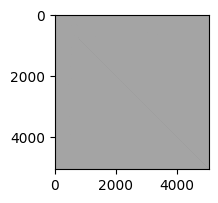

In [ ]:
plot_image(U1)
plot_image(U2)
plot_image(U3)

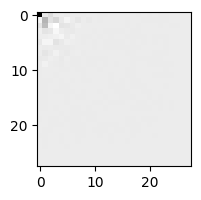

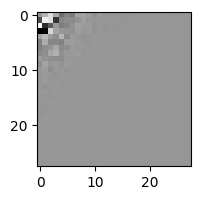

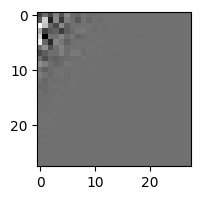

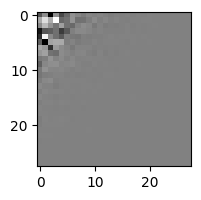

In [ ]:
plot_image(S[:,:,0])
plot_image(S[:,:,1])
plot_image(S[:,:,2])
plot_image(S[:,:,3])

slice=0

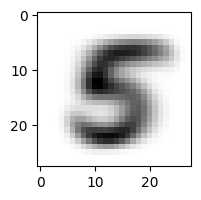

In [ ]:
Aj = U1.dot(S[:,:,0]).dot(U2.T)
plot_image(Aj)

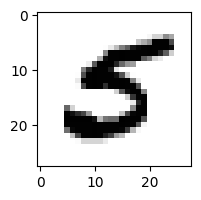

In [ ]:
Z = x_Train[y_Train == 5][0].reshape([28, 28])
plot_image(Z)

In [ ]:
 Zj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj)
 Zj

0.01953337895137826

In [ ]:
G = np.linalg.norm(Z-Zj*Aj,"fro")
G

6.600853652065828

In [ ]:
U1, U2, U3 = U_list[5]
S = S_list[5]
S.shape, U1.shape, U2.shape, U3.shape

((28, 28, 5050), (28, 28), (28, 28), (5050, 5050))

slice=27

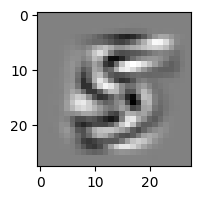

In [ ]:
Aj = U1.dot(S[:,:,27]).dot(U2.T)
plot_image(Aj)

In [ ]:
 Zj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj)
 Zj

-0.0019204287558145148

In [ ]:
G = np.linalg.norm(Z-Zj*Aj, "fro")
G

11.108999027176914

In [ ]:
# Train dataset
result_Train_list, y_Train_predict, result_Train_predict, result_Train_residual, result_Train_mse = hosvdAlgorithm(x_Train, y_Train, S_list, U_list, 27)

In [ ]:
result_Train_predict

0.9581964285714286

In [ ]:
# result_Train_residual[7290]
result_Train_residual[np.where(y_Train == 5)[0][0]]

array([5.63011377, 6.88689907, 6.07898361, 5.17719297, 7.34424804,
       2.80375359, 5.68119418, 7.24769577, 5.85880673, 6.46456827])

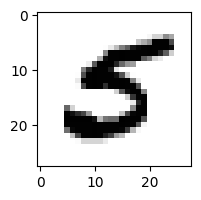

In [ ]:
plot_image(x_Train[np.where(y_Train == 5)[0][0]].reshape([28, 28]))

In [ ]:
result_Train_mse

[3.5655892857142857,
 2.5077857142857143,
 1.6785892857142857,
 1.497625,
 1.3458571428571429,
 1.224,
 1.092517857142857,
 1.0325892857142858,
 0.9849821428571428,
 0.983,
 0.9659107142857143,
 0.9287321428571429,
 0.8989285714285714,
 0.8966607142857143,
 0.8718392857142857,
 0.8618035714285714,
 0.8461607142857143,
 0.8388214285714286,
 0.8265714285714286,
 0.7953035714285714,
 0.7855178571428572,
 0.7820178571428571,
 0.7594107142857143,
 0.7713392857142857,
 0.7672142857142857,
 0.7704642857142857,
 0.7715178571428571]

Text(0.5, 0, 'number of basis')

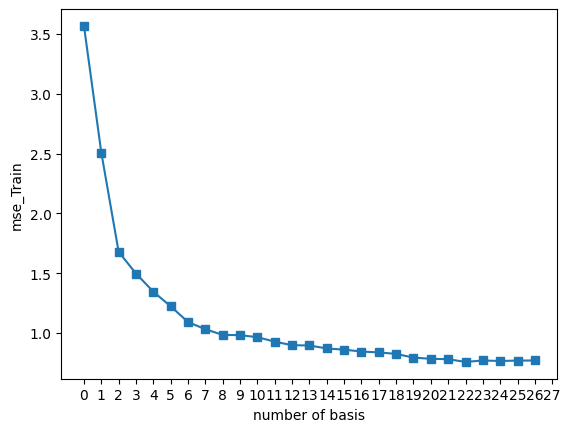

In [ ]:
plt.plot(result_Train_mse,'s-')
plt.xticks(range(0,28))
plt.ylabel('mse_Train')
plt.xlabel('number of basis')

In [ ]:
# Test dataset
result_Test_list, y_Test_predict, result_Test_predict, result_Test_residual, result_Test_mse = hosvdAlgorithm(x_Test, y_Test, S_list, U_list, 27)

In [ ]:
result_Test_predict

0.9548571428571428

In [ ]:
result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']].shape[0]

632

In [ ]:
result_Test_residual[np.where(y_Test == 5)[0][0]]

array([4.4544538 , 6.20186154, 5.7151676 , 3.80754852, 6.47174118,
       3.10487801, 4.37740447, 5.7083858 , 4.72702163, 4.97286278])

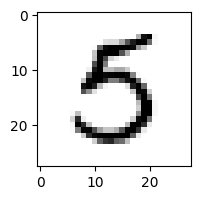

In [ ]:
plot_image(x_Test[np.where(y_Test == 5)[0][0]].reshape([28, 28]))

Predict wrong

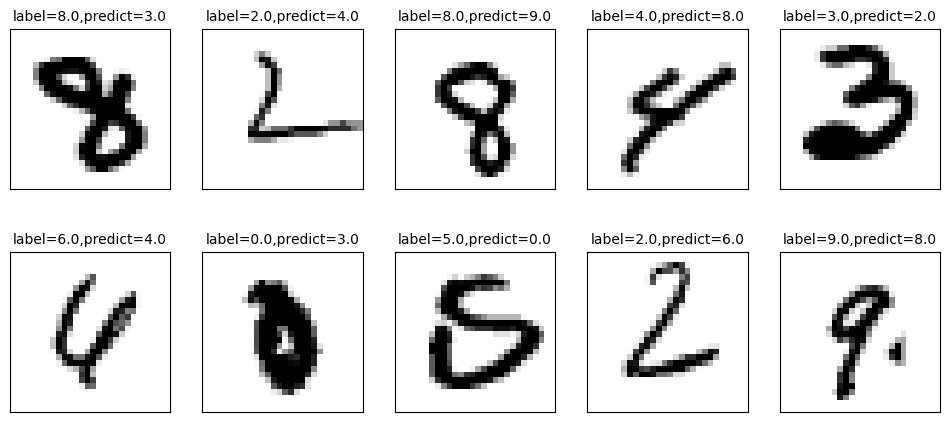

In [ ]:
errorList = result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']]

errorList.shape

plot_images_labels_prediction(errorList.iloc[:,np.arange(0, 784)], errorList.iloc[:,[784]], errorList.iloc[:,[785]],0,10)

In [ ]:
totalCounts = result_Test_list[['actual']].groupby(['actual']).size().reset_index(name='totalCounts')
totalCounts = totalCounts.sort_values('actual', ascending=[True])
errorCounts = errorList[['actual']].groupby(['actual']).size().reset_index(name='errorCounts')
errorCounts = errorCounts.sort_values('actual', ascending=[True])
resultdf = pd.concat([totalCounts,pd.DataFrame(errorCounts, columns=['errorCounts'])], axis=1)
resultdf["successCounts"] = resultdf["totalCounts"]-resultdf["errorCounts"]
resultdf["probability"] = (resultdf["totalCounts"]-resultdf["errorCounts"])/resultdf["totalCounts"]
resultdf.sort_values('probability', ascending=[False])

,actual,totalCounts,errorCounts,successCounts,probability
0,0.0,1381,17,1364,0.987690
1,1.0,1575,22,1553,0.986032
6,6.0,1375,37,1338,0.973091
4,4.0,1365,50,1315,0.963370
2,2.0,1398,72,1326,0.948498
7,7.0,1459,78,1381,0.946539
9,9.0,1391,84,1307,0.939612
5,5.0,1263,80,1183,0.936659
3,3.0,1428,93,1335,0.934874
8,8.0,1365,99,1266,0.927473


In [ ]:
# 計算每個 (digital, prediction) 的錯誤次數
temp = (
    errorList[['actual', 'prediction']]
    .groupby(['actual', 'prediction'])
    .size()
    .reset_index(name='counts')
)

# 建立空的錯誤預測矩陣：4 × 10
errorPrediction = np.zeros((4, 10))

# 對每個真實數字 i，找出最常見的兩個錯誤預測
for i in range(10):
  top_errors = (
      temp[temp['actual'] == i]
      .sort_values('counts', ascending=False)
      .head(2)
  )
  if len(top_errors) > 0:
      errorPrediction[0][i] = top_errors.iloc[0]['prediction']
      errorPrediction[1][i] = top_errors.iloc[0]['counts']
  if len(top_errors) > 1:
      errorPrediction[2][i] = top_errors.iloc[1]['prediction']
      errorPrediction[3][i] = top_errors.iloc[1]['counts']

# 包裝成 DataFrame
error_df = pd.DataFrame(errorPrediction, columns=np.arange(10))
error_df.index = ["1st wrongly predicted digit", "Qty", "2nd wrongly predicted digit", "Qty"]
error_df

,0,1,2,3,4,5,6,7,8,9
1st wrongly predicted digit,8.0,2.0,8.0,8.0,9.0,3.0,5.0,9.0,3.0,7.0
Qty,6.0,10.0,22.0,36.0,21.0,27.0,12.0,46.0,20.0,20.0
2nd wrongly predicted digit,1.0,7.0,7.0,0.0,1.0,8.0,0.0,2.0,1.0,3.0
Qty,4.0,6.0,13.0,14.0,8.0,19.0,8.0,10.0,19.0,14.0


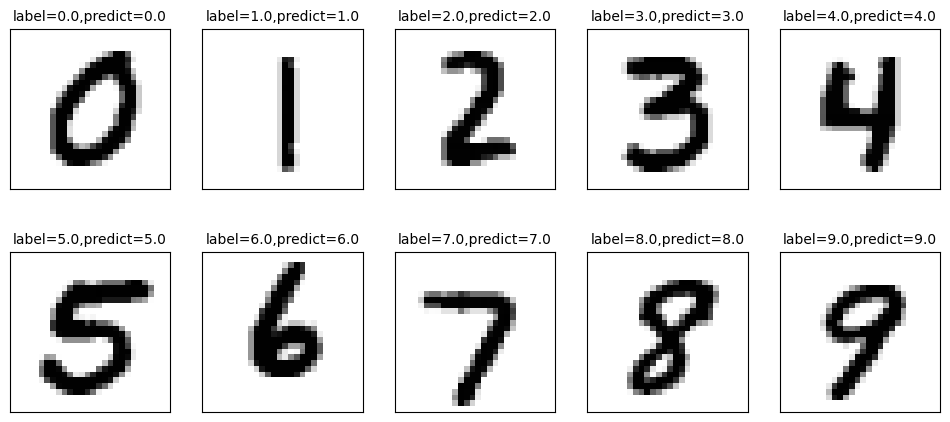

In [ ]:
minList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['min']})


niceIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    niceIndex[i] = int(digitalList[digitalList['residual'] == minList['residual']['min'][i]].index.values[0])

niceList = result_Test_list.iloc[result_Test_list.index.get_indexer(niceIndex)]

plot_images_labels_prediction(niceList.iloc[:,np.arange(0, 784)], niceList.iloc[:,[784]], niceList.iloc[:,[785]],0,10)

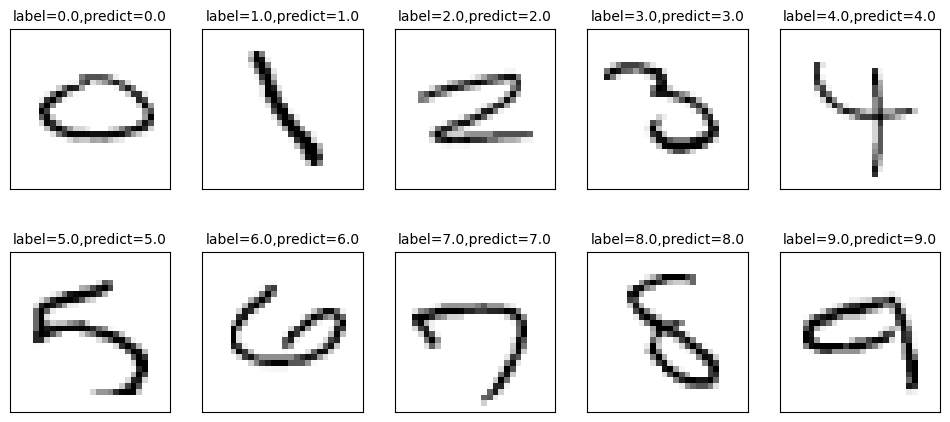

In [ ]:
maxList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['max']})

uglyIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    uglyIndex[i] = int(digitalList[digitalList['residual'] == maxList['residual']['max'][i]].index.values[0])

uglyList = result_Test_list.iloc[result_Test_list.index.get_indexer(uglyIndex)]

plot_images_labels_prediction(uglyList.iloc[:,np.arange(0, 784)], uglyList.iloc[:,[784]], uglyList.iloc[:,[785]],0,10)

In [ ]:
result_Test_residual[np.where(y_Test == 3)[0][0]]

array([0.64700431, 0.54032218, 0.68375236, 0.38003317, 0.60736144,
       0.48426226, 0.72045332, 0.61546105, 0.3981407 , 0.52770752])

In [ ]:
result_Test_mse

[3.4630714285714284,
 2.451357142857143,
 1.7382857142857142,
 1.6050714285714285,
 1.4315,
 1.3508571428571428,
 1.185142857142857,
 1.1183571428571428,
 1.1015714285714286,
 1.0619285714285713,
 1.0165,
 0.9631428571428572,
 0.9814285714285714,
 1.0186428571428572,
 0.9762857142857143,
 0.9335714285714286,
 0.8853571428571428,
 0.8833571428571428,
 0.8997857142857143,
 0.9048571428571428,
 0.8936428571428572,
 0.8972857142857142,
 0.8754285714285714,
 0.8785,
 0.8481428571428572,
 0.8402142857142857,
 0.872]

Text(0.5, 0, 'number of basis')

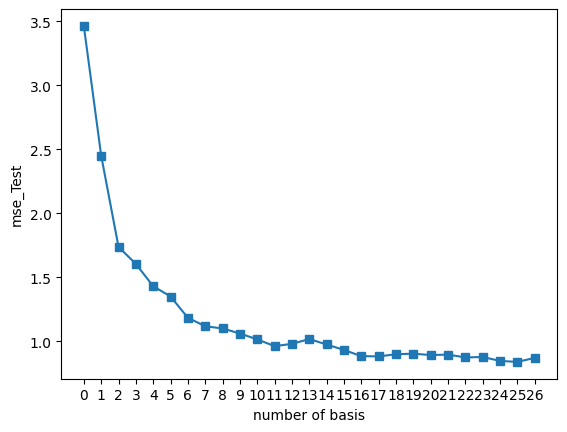

In [ ]:
plt.plot(result_Test_mse,'s-')
plt.xticks(range(0,27))
plt.ylabel('mse_Test')
plt.xlabel('number of basis')

Digit 0

In [ ]:
components = np.where(y_Test == 0)[0]
components
x_Test_0 = x_Test[components, :]
y_Test_0 = np.full(x_Test_0.shape[0],0)

In [ ]:
result_Test_0_list, y_Test_0_predict, result_Test_0_predict, result_Test_0_residual, result_Test_0_mse = hosvdAlgorithm(x_Test_0, y_Test_0, S_list, U_list, 27)

In [ ]:
result_Test_0_predict

0.9876900796524257

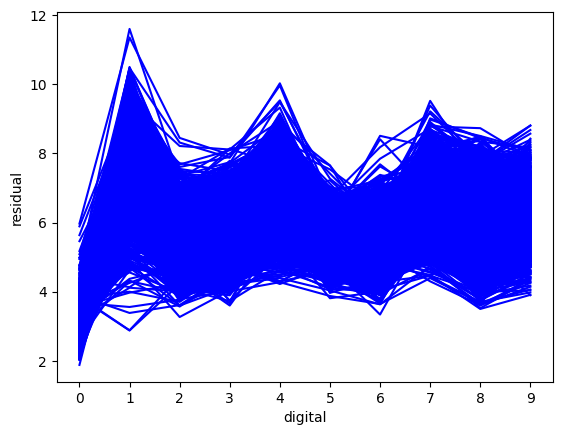

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_0.shape[0]):
    plt.plot(result_Test_0_residual[i],color = 'blue')

Digit 1

In [ ]:
components = np.where(y_Test == 1)[0]
components
x_Test_1 = x_Test[components, :]
y_Test_1 = np.full(x_Test_1.shape[0],1)

In [ ]:
result_Test_1_list, y_Test_1_predict, result_Test_1_predict, result_Test_1_residual, result_Test_1_mse = hosvdAlgorithm(x_Test_1, y_Test_1, S_list, U_list, 27)

In [ ]:
result_Test_1_predict

0.986031746031746

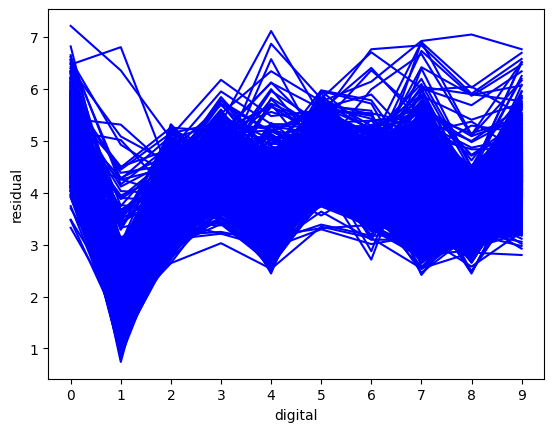

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_1.shape[0]):
    plt.plot(result_Test_1_residual[i],color = 'blue')

Digit 8

In [ ]:
components = np.where(y_Test == 8)[0]
components
x_Test_8 = x_Test[components, :]
y_Test_8 = np.full(x_Test_8.shape[0],8)

In [ ]:
result_Test_8_list, y_Test_8_predict, result_Test_8_predict, result_Test_8_residual, result_Test_8_mse = hosvdAlgorithm(x_Test_8, y_Test_8, S_list, U_list, 27)

In [ ]:
result_Test_8_predict

0.9274725274725275

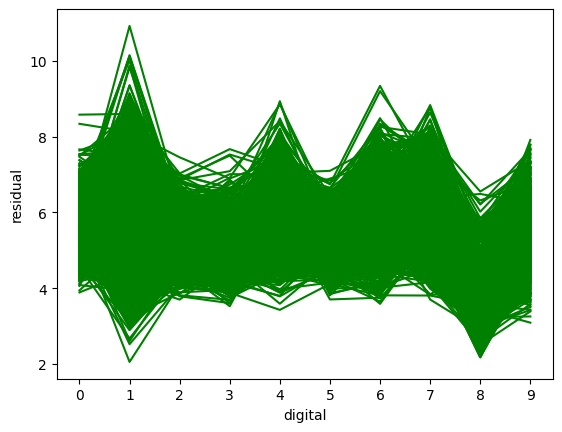

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_8.shape[0]):
    plt.plot(result_Test_8_residual[i],color = 'green')

Digit 3

In [ ]:
components = np.where(y_Test == 3)[0]
components
x_Test_3 = x_Test[components, :]
y_Test_3 = np.full(x_Test_3.shape[0],3)

In [ ]:
result_Test_3_list, y_Test_3_predict, result_Test_3_predict, result_Test_3_residual, result_Test_3_mse = hosvdAlgorithm(x_Test_3, y_Test_3, S_list, U_list, 27)

In [ ]:
result_Test_3_predict

0.9348739495798319

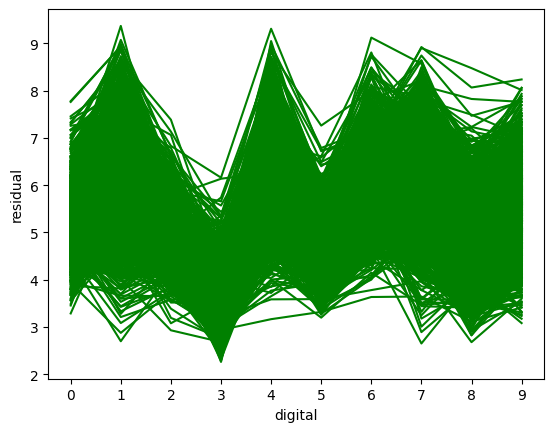

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_3.shape[0]):
    plt.plot(result_Test_3_residual[i],color = 'green')

My own data

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son1_list, y_son1_predict, result_son1_predict, result_son1_residual, result_son1_mse = hosvdAlgorithm(x_son1, y_son1, S_list, U_list, 27)
result_son1_predict

0.5

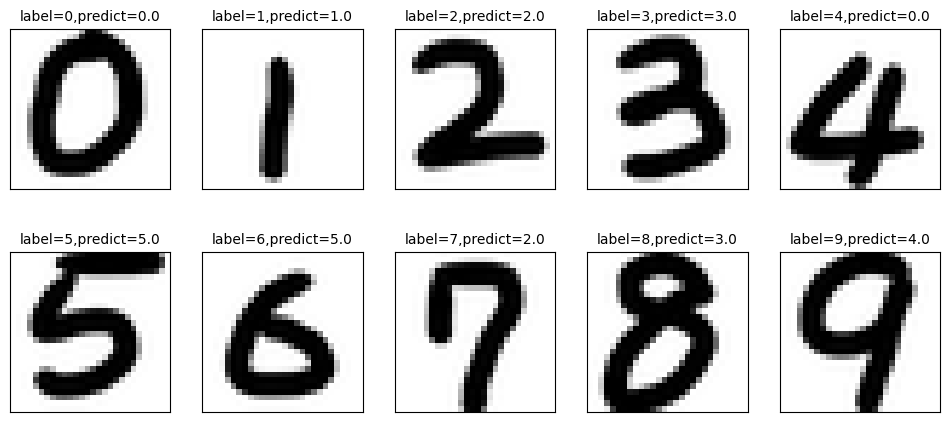

In [ ]:
plot_images_labels_prediction(result_son1_list.iloc[:,np.arange(0, 784)], result_son1_list.iloc[:,[784]], result_son1_list.iloc[:,[785]],0,10)

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son2_list, y_son2_predict, result_son2_predict, result_son2_residual, result_son2_mse = hosvdAlgorithm(x_son2, y_son2, S_list, U_list, 27)
result_son2_predict

0.7

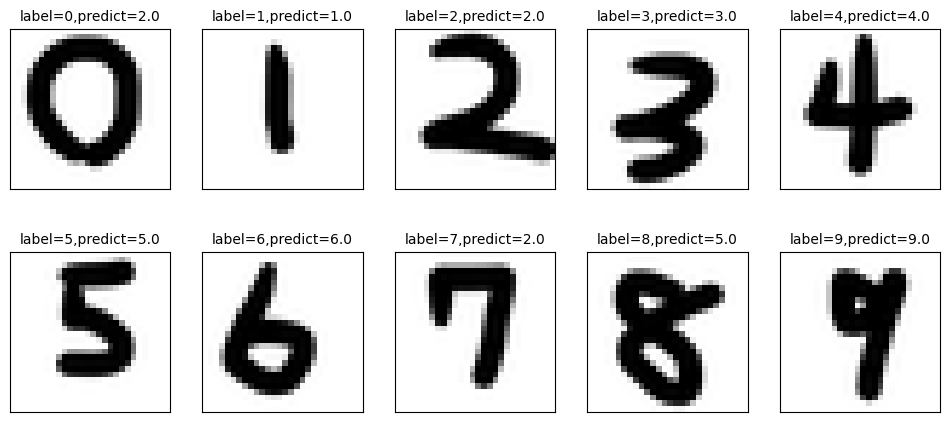

In [ ]:
plot_images_labels_prediction(result_son2_list.iloc[:,np.arange(0, 784)], result_son2_list.iloc[:,[784]], result_son2_list.iloc[:,[785]],0,10)

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son3_list, y_son3_predict, result_son3_predict, result_son3_residual, result_son3_mse = hosvdAlgorithm(x_son3, y_son3, S_list, U_list, 27)
result_son3_predict

0.5

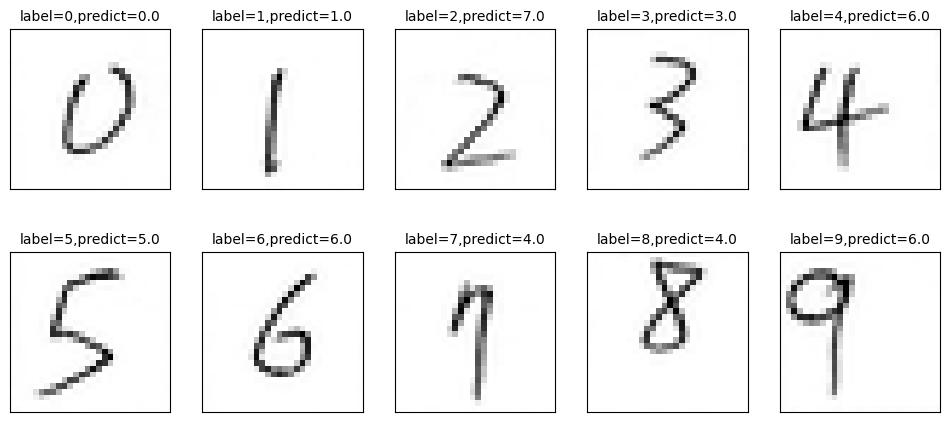

In [ ]:
plot_images_labels_prediction(result_son3_list.iloc[:,np.arange(0, 784)], result_son3_list.iloc[:,[784]], result_son3_list.iloc[:,[785]],0,10)

In [ ]:
# @title
# Record all the results
overall_pred_res("HoSVD", [result_Test_predict, result_son1_predict, result_son2_predict])

# Classification Using Random Forest (隨機森林演算法)

In [ ]:
x_Train, y_Train, x_Test, y_Test = getMnistDataSet()
print("training set (28x28) : %d piece(s)" % x_Train.shape[0])
print("testing set (28x28) : %d piece(s)" % x_Test.shape[0])

training set (28x28) : 56000 piece(s)
testing set (28x28) : 14000 piece(s)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, classification_report, accuracy_score

In [ ]:
forest = RandomForestClassifier(criterion='gini',
                                n_estimators=300,
                                max_depth = 10,
                                max_features='sqrt',
                                min_samples_split=4,
                                min_samples_leaf=2,
                                random_state=3,
                                n_jobs=2)

In [ ]:
forest.fit(x_Train,y_Train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_Train_pred = forest.predict(x_Train)
accuracy_score(y_Train, y_Train_pred)

0.9662321428571429

In [ ]:
y_Test_pred = forest.predict(x_Test)

In [ ]:
prediction_data = pd.concat([pd.DataFrame(y_Test, columns=['actual']), pd.DataFrame(y_Test_pred, columns=['prediction'])], axis=1)

result = prediction_data[prediction_data['actual'] == prediction_data['prediction']].shape[0]/prediction_data.shape[0]
result

0.9377179870453413

In [ ]:
accuracy_score(y_Test, y_Test_pred)

0.9450714285714286

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)).flatten()

In [ ]:
y_son1_pred = forest.predict(x_son1)

In [ ]:
prediction_data = pd.concat([pd.DataFrame(y_son1, columns=['actual']), pd.DataFrame(y_son1_pred, columns=['prediction'])], axis=1)

result_son1_predict = prediction_data[prediction_data['actual'] == prediction_data['prediction']].shape[0]/prediction_data.shape[0]
result_son1_predict

0.3

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)).flatten()

In [ ]:
y_son2_pred = forest.predict(x_son2)

In [ ]:
prediction_data = pd.concat([pd.DataFrame(y_son2, columns=['actual']), pd.DataFrame(y_son2_pred, columns=['prediction'])], axis=1)

result_son2_predict = prediction_data[prediction_data['actual'] == prediction_data['prediction']].shape[0]/prediction_data.shape[0]
result_son2_predict

0.3

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)).flatten()

In [ ]:
y_son3_pred = forest.predict(x_son3)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print(accuracy_score(y_son3, y_son3_pred))

0.5


In [ ]:
# Record all the results
overall_pred_res("RandomForest", [result, result_son1_predict, result_son2_predict])

# Other ML Models: SVM/DecisionTree/Voting/Bagging/Boosting/Stacking

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    VotingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression


# 3. 定義基礎模型
svm_clf = SVC(kernel="rbf", gamma="scale", C=5, probability=True, random_state=42)
dt_clf = DecisionTreeClassifier(max_depth=30, max_features='sqrt', random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Voting (硬投票 / 軟投票)
voting_clf = VotingClassifier(
    estimators=[("svm", svm_clf), ("dt", dt_clf), ("rf", rf_clf)],
    voting="soft"   # "hard" 也可
)

# 5. Bagging (以 Decision Tree 為基底)
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

# 6. Boosting (AdaBoost + GradientBoosting)
adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# 7. Stacking (以 Logistic Regression 為次級分類器)
stacking_clf = StackingClassifier(
    estimators=[("svm", svm_clf), ("dt", dt_clf), ("rf", rf_clf)],
    final_estimator=LogisticRegression(max_iter=100),
    passthrough=True
)

# 8. 模型清單
models = {
    "SVM": svm_clf,
    "DecisionTree": dt_clf,
    "Voting": voting_clf,
    "Bagging": bagging_clf,
    "AdaBoost": adaboost_clf,
    "GradientBoosting": gb_clf,
    "Stacking": stacking_clf
}

# 9. 訓練 & 評估
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(x_Train, y_Train)
    y_pred = model.predict(x_Test)
    acc = accuracy_score(y_Test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_Test, y_pred, digits=4))

# 10. 總結比較
print("\n=== Model Comparison ===")
for name, acc in results.items():
    print(f"{name}: {acc}")


Training SVM...
SVM Accuracy: 0.9833
              precision    recall  f1-score   support

         0.0     0.9822    0.9971    0.9896      1381
         1.0     0.9867    0.9917    0.9892      1575
         2.0     0.9828    0.9835    0.9832      1398
         3.0     0.9873    0.9797    0.9835      1428
         4.0     0.9823    0.9780    0.9802      1365
         5.0     0.9833    0.9778    0.9805      1263
         6.0     0.9876    0.9876    0.9876      1375
         7.0     0.9821    0.9801    0.9811      1459
         8.0     0.9838    0.9788    0.9813      1365
         9.0     0.9742    0.9770    0.9756      1391

    accuracy                         0.9833     14000
   macro avg     0.9832    0.9831    0.9832     14000
weighted avg     0.9833    0.9833    0.9833     14000


Training DecisionTree...
DecisionTree Accuracy: 0.8326
              precision    recall  f1-score   support

         0.0     0.9088    0.9232    0.9159      1381
         1.0     0.9364    0.9543    0

In [ ]:
y_son = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))
x_son2 = np.zeros((10,784))
x_son3 = np.zeros((10,784))

for i in range(10):
  img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
  x_son1[i,:] = (np.array(img)/255).flatten()

  img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
  x_son2[i,:] = (np.array(img)/255).flatten()

  img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
  x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
from sklearn.metrics import accuracy_score

results1 = {}
results2 = {}
results3 = {}
for name, model in models.items():
    # print(f"\nTraining {name}...")
    # model.fit(X_train, y_train)          # 訓練模型
    y_son1_pred = model.predict(x_son1)       # 測試集預測
    acc = accuracy_score(y_son, y_son1_pred) # 計算 accuracy
    results1[name] = acc
    print(f"{name} Accuracy: son1 {acc}")

    y_son2_pred = model.predict(x_son2)       # 測試集預測
    acc1 = accuracy_score(y_son, y_son2_pred) # 計算 accuracy
    results2[name] = acc1
    print(f"{name} Accuracy: son2 {acc1}")

    y_son3_pred = model.predict(x_son3)       # 測試集預測
    acc2 = accuracy_score(y_son, y_son3_pred) # 計算 accuracy
    results3[name] = acc2
    print(f"{name} Accuracy: son3 {acc2}")

# 總結比較
print("\n=== Model Comparison ===")
for name, acc in results1.items():
    print(f"{name}: son1 {acc}")

for name, acc in results2.items():
    print(f"{name}: son2 {acc}")

for name, acc in results3.items():
    print(f"{name}: son3 {acc}")

SVM Accuracy: son1 0.5
SVM Accuracy: son2 0.8
SVM Accuracy: son3 0.4
DecisionTree Accuracy: son1 0.2
DecisionTree Accuracy: son2 0.2
DecisionTree Accuracy: son3 0.2
Voting Accuracy: son1 0.4
Voting Accuracy: son2 0.5
Voting Accuracy: son3 0.4
Bagging Accuracy: son1 0.5
Bagging Accuracy: son2 0.4
Bagging Accuracy: son3 0.4
AdaBoost Accuracy: son1 0.2
AdaBoost Accuracy: son2 0.3
AdaBoost Accuracy: son3 0.1
GradientBoosting Accuracy: son1 0.3
GradientBoosting Accuracy: son2 0.5
GradientBoosting Accuracy: son3 0.4
Stacking Accuracy: son1 0.4
Stacking Accuracy: son2 0.8
Stacking Accuracy: son3 0.3

=== Model Comparison ===
SVM: son1 0.5
DecisionTree: son1 0.2
Voting: son1 0.4
Bagging: son1 0.5
AdaBoost: son1 0.2
GradientBoosting: son1 0.3
Stacking: son1 0.4
SVM: son2 0.8
DecisionTree: son2 0.2
Voting: son2 0.5
Bagging: son2 0.4
AdaBoost: son2 0.3
GradientBoosting: son2 0.5
Stacking: son2 0.8
SVM: son3 0.4
DecisionTree: son3 0.2
Voting: son3 0.4
Bagging: son3 0.4
AdaBoost: son3 0.1
GradientB

In [ ]:
# Record all the results
for idx, (name, acc) in enumerate(results.items()):
  # print(idx,name,acc)
  table = overall_pred_res(name, [acc, results1[name], results2[name]])

table

,Mean,SVD,HoSVD,RandomForest,SVM,DecisionTree,Voting,Bagging,AdaBoost,GradientBoosting,Stacking
test accuracy,0.776781,0.934728,0.934728,0.916791,0.953164,0.829098,0.927255,0.897359,0.840558,0.927753,0.942701
my data 1,0.500000,0.700000,0.700000,0.700000,1.000000,0.400000,0.700000,0.600000,0.300000,0.800000,1.000000
my data 2,0.600000,0.300000,0.300000,0.300000,0.700000,0.300000,0.400000,0.400000,0.500000,0.600000,0.500000


# Classification Using MLP (多層感知器)

In [ ]:
!conda install -c conda-forge cudatoolkit cudnn
!pip install tensorflow

In [ ]:
!python -m pip install tensorflow

In [ ]:
!python -m pip install --upgrade pip
!python -m pip install tensorflow

In [ ]:
!python -m pip list | grep tensorflow

tensorflow                   2.10.0
tensorflow-estimator         2.10.0
tensorflow-io-gcs-filesystem 0.37.1


In [ ]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())

In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.10.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/sw/.local/lib/python3.10/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, keras-preprocessing, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 


In [ ]:
!which python
!which pip
!pip list | grep tensorflow

/usr/bin/python
/home/sw/.local/bin/pip
tensorflow                   2.10.0
tensorflow-estimator         2.10.0
tensorflow-io-gcs-filesystem 0.37.1


In [ ]:
!python -m pip install tensorflow

In [ ]:
!pip install numpy==1.26.4 --force-reinstall

In [ ]:
!pip install "opencv-python<4.8" --force-reinstall

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [ ]:
# @title
x_Train, y_Train, x_Test, y_Test = getMnistDataSet()
print("training set (28x28) : %d piece(s)" % x_Train.shape[0])
print("testing set (28x28) : %d piece(s)" % x_Test.shape[0])

training set (28x28) : 56000 piece(s)
testing set (28x28) : 14000 piece(s)


In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
model = Sequential([
    Input(shape=(784,)),  # ✅ 用 Input() 明確定義輸入形狀
    Dense(784, kernel_initializer='normal', activation='relu'),
    Dense(784, kernel_initializer='normal', activation='relu'),
    Dense(10, kernel_initializer='normal', activation='softmax')
])

2025-12-05 20:55:07.531723: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# @title
model = Sequential()
model.add(Dense(input_dim=784,
                units=784,
                kernel_initializer='normal',
                activation='relu'))

model.add(Dense(units=784,
                kernel_initializer='normal',
                activation='relu'))

model.add(Dense(units=10,
                kernel_initializer='normal',
                activation='softmax'))

In [ ]:
# @title
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

train_history = model.fit(
    x=x_Train,
    y=y_TrainOneHot,
    validation_split=0.2,
    epochs=20,
    batch_size=300,
    verbose=2,
    callbacks=callbacks
)

Epoch 1/20
150/150 - 1s - loss: 0.2693 - accuracy: 0.9204 - val_loss: 0.1284 - val_accuracy: 0.9604 - lr: 0.0010 - 1s/epoch - 8ms/step
Epoch 2/20
150/150 - 1s - loss: 0.0938 - accuracy: 0.9712 - val_loss: 0.0976 - val_accuracy: 0.9681 - lr: 0.0010 - 775ms/epoch - 5ms/step
Epoch 3/20
150/150 - 1s - loss: 0.0517 - accuracy: 0.9842 - val_loss: 0.0831 - val_accuracy: 0.9740 - lr: 0.0010 - 840ms/epoch - 6ms/step
Epoch 4/20
150/150 - 1s - loss: 0.0325 - accuracy: 0.9901 - val_loss: 0.0854 - val_accuracy: 0.9745 - lr: 0.0010 - 768ms/epoch - 5ms/step
Epoch 5/20
150/150 - 1s - loss: 0.0215 - accuracy: 0.9937 - val_loss: 0.0756 - val_accuracy: 0.9787 - lr: 0.0010 - 759ms/epoch - 5ms/step
Epoch 6/20
150/150 - 1s - loss: 0.0166 - accuracy: 0.9949 - val_loss: 0.0723 - val_accuracy: 0.9784 - lr: 0.0010 - 761ms/epoch - 5ms/step
Epoch 7/20
150/150 - 1s - loss: 0.0103 - accuracy: 0.9970 - val_loss: 0.0847 - val_accuracy: 0.9769 - lr: 0.0010 - 749ms/epoch - 5ms/step
Epoch 8/20
150/150 - 1s - loss: 0.008

In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train,
                        y=y_TrainOneHot,validation_split=0.2,
                        epochs=20, batch_size=300,verbose=2)

Epoch 1/20
150/150 - 1s - loss: 0.0146 - accuracy: 0.9951 - val_loss: 0.1085 - val_accuracy: 0.9735 - 954ms/epoch - 6ms/step
Epoch 2/20
150/150 - 1s - loss: 0.0135 - accuracy: 0.9955 - val_loss: 0.0938 - val_accuracy: 0.9780 - 746ms/epoch - 5ms/step
Epoch 3/20
150/150 - 1s - loss: 0.0078 - accuracy: 0.9976 - val_loss: 0.0985 - val_accuracy: 0.9780 - 761ms/epoch - 5ms/step
Epoch 4/20
150/150 - 1s - loss: 0.0090 - accuracy: 0.9969 - val_loss: 0.1180 - val_accuracy: 0.9738 - 753ms/epoch - 5ms/step
Epoch 5/20
150/150 - 1s - loss: 0.0102 - accuracy: 0.9967 - val_loss: 0.0960 - val_accuracy: 0.9793 - 768ms/epoch - 5ms/step
Epoch 6/20
150/150 - 1s - loss: 0.0038 - accuracy: 0.9989 - val_loss: 0.0913 - val_accuracy: 0.9815 - 809ms/epoch - 5ms/step
Epoch 7/20
150/150 - 1s - loss: 0.0022 - accuracy: 0.9995 - val_loss: 0.0942 - val_accuracy: 0.9808 - 790ms/epoch - 5ms/step
Epoch 8/20
150/150 - 1s - loss: 0.0055 - accuracy: 0.9983 - val_loss: 0.1273 - val_accuracy: 0.9752 - 852ms/epoch - 6ms/step


In [ ]:
scores_test = model.evaluate(x_Test , y_TestOneHot)
scores_test[1]

438/438 [==============================] - 0s 803us/step - loss: 0.0964 - accuracy: 0.9835


0.9835000038146973

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son1 , y_son1OneHot)
scores_son1[1]

1/1 [==============================] - 0s 12ms/step - loss: 8.0609 - accuracy: 0.5000


0.5

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
y_son2OneHot =to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son2 , y_son2OneHot)
scores_son2[1]

1/1 [==============================] - 0s 11ms/step - loss: 0.7384 - accuracy: 0.9000


0.8999999761581421

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
y_son3OneHot =to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son3 , y_son3OneHot)
scores_son3[1]

1/1 [==============================] - 0s 11ms/step - loss: 4.3476 - accuracy: 0.6000


0.6000000238418579

In [ ]:
# Record all the results
overall_pred_res("MLP", [scores_test[1], scores_son1[1], scores_son2[1]])

,Mean,SVD,HoSVD,RandomForest,SVM,DecisionTree,Voting,Bagging,AdaBoost,GradientBoosting,Stacking,MLP
test accuracy,0.776781,0.934728,0.934728,0.916791,0.953164,0.829098,0.927255,0.897359,0.840558,0.927753,0.942701,0.931241
my data 1,0.500000,0.700000,0.700000,0.700000,1.000000,0.400000,0.700000,0.600000,0.300000,0.800000,1.000000,0.800000
my data 2,0.600000,0.300000,0.300000,0.300000,0.700000,0.300000,0.400000,0.400000,0.500000,0.600000,0.500000,0.500000


# Classification Using CNN (卷積神經網路)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [ ]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (28x28) : %d piece(s)" % x_Train.shape[0])
print("testing set (28x28) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
x_Train_tensor = x_Train.reshape(len(x_Train), 28, 28).astype('float32')
x_Test_tensor = x_Test.reshape(len(x_Test), 28, 28).astype('float32')

In [ ]:
# 多加一個顏色的維度
x_Train4D=x_Train_tensor.reshape(x_Train_tensor.shape[0],28,28,1).astype('float32')
x_Test4D=x_Test_tensor.reshape(x_Test_tensor.shape[0],28,28,1).astype('float32')

In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential([
    # ✅ 使用 Input() 明確定義輸入形狀
    Input(shape=(28, 28, 1)),

    # 第一層卷積 + Pooling
    Conv2D(filters=16, kernel_size=(5, 5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # 第二層卷積 + Pooling
    Conv2D(filters=36, kernel_size=(5, 5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Dropout 防止 overfitting
    Dropout(0.25),

    # 平坦化
    Flatten(),

    # 全連接層
    Dense(units=784, activation='relu'),
    Dropout(0.5),
    Dense(units=10, activation='softmax')  # 多分類輸出
])

In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train4D,
            y=y_TrainOneHot,validation_split=0.2,
            epochs=20, batch_size=300,verbose=2)

Epoch 1/20
150/150 - 5s - loss: 0.3222 - accuracy: 0.9000 - val_loss: 0.0858 - val_accuracy: 0.9744 - 5s/epoch - 30ms/step
Epoch 2/20
150/150 - 4s - loss: 0.0876 - accuracy: 0.9722 - val_loss: 0.0596 - val_accuracy: 0.9810 - 4s/epoch - 27ms/step
Epoch 3/20
150/150 - 4s - loss: 0.0623 - accuracy: 0.9803 - val_loss: 0.0468 - val_accuracy: 0.9856 - 4s/epoch - 28ms/step
Epoch 4/20
150/150 - 4s - loss: 0.0478 - accuracy: 0.9848 - val_loss: 0.0465 - val_accuracy: 0.9849 - 4s/epoch - 25ms/step
Epoch 5/20
150/150 - 4s - loss: 0.0403 - accuracy: 0.9873 - val_loss: 0.0387 - val_accuracy: 0.9879 - 4s/epoch - 26ms/step
Epoch 6/20
150/150 - 4s - loss: 0.0345 - accuracy: 0.9888 - val_loss: 0.0391 - val_accuracy: 0.9883 - 4s/epoch - 24ms/step
Epoch 7/20
150/150 - 4s - loss: 0.0312 - accuracy: 0.9896 - val_loss: 0.0362 - val_accuracy: 0.9894 - 4s/epoch - 26ms/step
Epoch 8/20
150/150 - 4s - loss: 0.0277 - accuracy: 0.9912 - val_loss: 0.0335 - val_accuracy: 0.9896 - 4s/epoch - 27ms/step
Epoch 9/20
150/1

In [ ]:
scores_test = model.evaluate(x_Test4D , y_TestOneHot)
scores_test[1]

438/438 [==============================] - 0s 1ms/step - loss: 0.0297 - accuracy: 0.9920


0.9919999837875366

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son1_tensor = x_son1.reshape(len(x_son1), 28, 28).astype('float32')
x_son14D=x_son1_tensor.reshape(x_son1_tensor.shape[0],28,28,1).astype('float32')
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son14D , y_son1OneHot)
scores_son1[1]

1/1 [==============================] - 0s 21ms/step - loss: 2.2025 - accuracy: 0.7000


0.699999988079071

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_tensor = x_son2.reshape(len(x_son2), 28, 28).astype('float32')
x_son24D=x_son2_tensor.reshape(x_son2_tensor.shape[0],28,28,1).astype('float32')
y_son2OneHot = to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son24D , y_son2OneHot)
scores_son2[1]

1/1 [==============================] - 0s 11ms/step - loss: 0.2294 - accuracy: 0.9000


0.8999999761581421

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_tensor = x_son3.reshape(len(x_son3), 28, 28).astype('float32')
x_son34D=x_son3_tensor.reshape(x_son3_tensor.shape[0],28,28,1).astype('float32')
y_son3OneHot = to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son34D , y_son3OneHot)
scores_son3[1]

1/1 [==============================] - 0s 12ms/step - loss: 1.9948 - accuracy: 0.8000


0.800000011920929

In [ ]:
# Record all the results
overall_pred_res("CNN", [scores_test[1], scores_son1[1], scores_son2[1]])

# Classification Using RNN (循環神經網路)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,SimpleRNN
from tensorflow.keras.utils import to_categorical

In [ ]:
x_Train, y_Train, x_Test, y_Test = getMnistDataSet()
print("training set (28x28) : %d piece(s)" % x_Train.shape[0])
print("testing set (28x28) : %d piece(s)" % x_Test.shape[0])

training set (28x28) : 56000 piece(s)
testing set (28x28) : 14000 piece(s)


In [ ]:
x_Train_tensor = x_Train.reshape(len(x_Train), 28, 28).astype('float32')
x_Test_tensor = x_Test.reshape(len(x_Test), 28, 28).astype('float32')

In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dropout, Dense

model = Sequential([
    Input(shape=(28, 28)),  # ✅ 使用 Input() 定義時間步長與特徵數
    SimpleRNN(units=784, unroll=True),
    Dropout(0.1),
    Dense(units=10, kernel_initializer='normal', activation='softmax')
])

In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train_tensor,
            y=y_TrainOneHot,validation_split=0.2,
            epochs=20, batch_size=300,verbose=2)

Epoch 1/20
150/150 - 11s - loss: 0.4541 - accuracy: 0.8583 - val_loss: 0.2370 - val_accuracy: 0.9271 - 11s/epoch - 72ms/step
Epoch 2/20
150/150 - 10s - loss: 0.2086 - accuracy: 0.9371 - val_loss: 0.1789 - val_accuracy: 0.9478 - 10s/epoch - 68ms/step
Epoch 3/20
150/150 - 10s - loss: 0.1771 - accuracy: 0.9465 - val_loss: 0.1436 - val_accuracy: 0.9571 - 10s/epoch - 68ms/step
Epoch 4/20
150/150 - 10s - loss: 0.1422 - accuracy: 0.9569 - val_loss: 0.1753 - val_accuracy: 0.9462 - 10s/epoch - 69ms/step
Epoch 5/20
150/150 - 10s - loss: 0.1321 - accuracy: 0.9606 - val_loss: 0.1320 - val_accuracy: 0.9599 - 10s/epoch - 68ms/step
Epoch 6/20
150/150 - 10s - loss: 0.1255 - accuracy: 0.9624 - val_loss: 0.1459 - val_accuracy: 0.9556 - 10s/epoch - 69ms/step
Epoch 7/20
150/150 - 10s - loss: 0.1075 - accuracy: 0.9675 - val_loss: 0.1311 - val_accuracy: 0.9622 - 10s/epoch - 69ms/step
Epoch 8/20
150/150 - 10s - loss: 0.1074 - accuracy: 0.9672 - val_loss: 0.1363 - val_accuracy: 0.9613 - 10s/epoch - 69ms/step


In [ ]:
scores_test = model.evaluate(x_Test_tensor , y_TestOneHot)
scores_test[1]

438/438 [==============================] - 4s 9ms/step - loss: 0.0937 - accuracy: 0.9745


0.9745000004768372

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son1_tensor = x_son1.reshape(len(x_son1), 28, 28).astype('float32')
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son1_tensor , y_son1OneHot)
scores_son1[1]

1/1 [==============================] - 0s 16ms/step - loss: 1.6767 - accuracy: 0.6000


0.6000000238418579

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_tensor = x_son2.reshape(len(x_son2), 28, 28).astype('float32')
y_son2OneHot = to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son2_tensor , y_son2OneHot)
scores_son2[1]

1/1 [==============================] - 0s 15ms/step - loss: 1.0061 - accuracy: 0.7000


0.699999988079071

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_tensor = x_son3.reshape(len(x_son3), 28, 28).astype('float32')
y_son3OneHot = to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son3_tensor , y_son3OneHot)
scores_son3[1]

1/1 [==============================] - 0s 15ms/step - loss: 2.1066 - accuracy: 0.7000


0.699999988079071

In [ ]:
# @title
# Record all the results
overall_pred_res("RNN", [scores_test[1], scores_son1[1], scores_son2[1]])

# Classification Using LSTM (長短期記憶循環神經網路)

In [ ]:
from keras.models import Sequential
from tensorflow.keras.layers import LSTM

In [ ]:
x_Train, y_Train, x_Test, y_Test = getMnistDataSet()
print("training set (28x28) : %d piece(s)" % x_Train.shape[0])
print("testing set (28x28) : %d piece(s)" % x_Test.shape[0])

training set (28x28) : 56000 piece(s)
testing set (28x28) : 14000 piece(s)


In [ ]:
x_Train_tensor = x_Train.reshape(len(x_Train), 28, 28).astype('float32')
x_Test_tensor = x_Test.reshape(len(x_Test), 28, 28).astype('float32')

In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
model = Sequential([
    Input(shape=(28, 28)),               # ✅ 定義輸入：16 時間步 × 16 特徵
    LSTM(units=784, unroll=False),      # LSTM 層，784 單元
    Dropout(0.1),                        # Dropout 防止過擬合
    Dense(units=10, kernel_initializer='normal', activation='softmax')  # 多分類輸出
])


In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train_tensor,
                        y=y_TrainOneHot,validation_split=0.2,
                        epochs=20, batch_size=300,verbose=2)

Epoch 1/20
150/150 - 23s - loss: 0.6002 - accuracy: 0.7953 - val_loss: 0.2630 - val_accuracy: 0.9177 - 23s/epoch - 155ms/step
Epoch 2/20
150/150 - 22s - loss: 0.1716 - accuracy: 0.9453 - val_loss: 0.1337 - val_accuracy: 0.9583 - 22s/epoch - 147ms/step
Epoch 3/20
150/150 - 22s - loss: 0.1197 - accuracy: 0.9623 - val_loss: 0.1235 - val_accuracy: 0.9621 - 22s/epoch - 146ms/step
Epoch 4/20
150/150 - 22s - loss: 0.0863 - accuracy: 0.9733 - val_loss: 0.0996 - val_accuracy: 0.9701 - 22s/epoch - 146ms/step
Epoch 5/20
150/150 - 22s - loss: 0.0729 - accuracy: 0.9768 - val_loss: 0.0732 - val_accuracy: 0.9785 - 22s/epoch - 146ms/step
Epoch 6/20
150/150 - 22s - loss: 0.0580 - accuracy: 0.9817 - val_loss: 0.0672 - val_accuracy: 0.9791 - 22s/epoch - 147ms/step
Epoch 7/20
150/150 - 22s - loss: 0.0478 - accuracy: 0.9852 - val_loss: 0.0581 - val_accuracy: 0.9835 - 22s/epoch - 146ms/step
Epoch 8/20
150/150 - 22s - loss: 0.0414 - accuracy: 0.9867 - val_loss: 0.0546 - val_accuracy: 0.9834 - 22s/epoch - 147

In [ ]:
scores_test = model.evaluate(x_Test_tensor , y_TestOneHot)
scores_test[1]

438/438 [==============================] - 5s 12ms/step - loss: 0.0601 - accuracy: 0.9860


0.9860000014305115

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son1_tensor = x_son1.reshape(len(x_son1), 28, 28).astype('float32')
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son1_tensor , y_son1OneHot)
scores_son1[1]

1/1 [==============================] - 0s 16ms/step - loss: 0.1738 - accuracy: 0.9000


0.8999999761581421

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_tensor = x_son2.reshape(len(x_son2), 28, 28).astype('float32')
y_son2OneHot = to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son2_tensor , y_son2OneHot)
scores_son2[1]

1/1 [==============================] - 0s 17ms/step - loss: 0.0456 - accuracy: 1.0000


1.0

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,784))

for i in range(10):
    img = Image.open("dataset/28x28/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_tensor = x_son3.reshape(len(x_son3), 28, 28).astype('float32')
y_son3OneHot = to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son3_tensor , y_son3OneHot)
scores_son3[1]

1/1 [==============================] - 0s 17ms/step - loss: 0.9376 - accuracy: 0.8000


0.800000011920929

In [ ]:
# @title
# Record all the results
overall_pred_res("LSTM", [scores_test[1], scores_son1[1], scores_son2[1]])

# Show overall the results


In [ ]:
# @title
df_table